In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
df = pd.read_csv('E:\ML with VS\material addition\Corrected\material_addition.csv')

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\SAIDUL\AppData\Local\Temp\ipykernel_14108\2072630213.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('E:\ML with VS\material addition\Corrected\material_addition.csv')


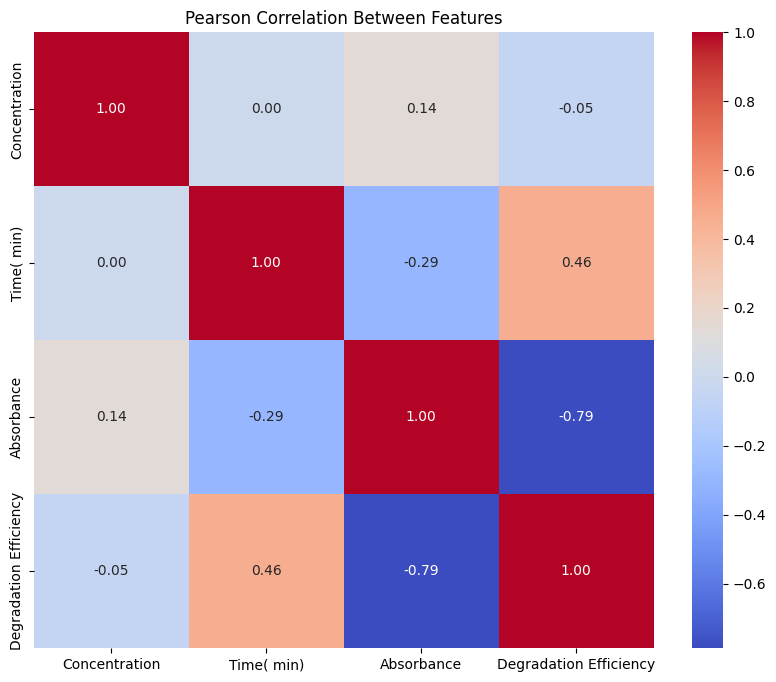

In [3]:


# Drop non-feature and target columns
features_df = df.drop(columns=["Nanomaterials Name"])

# Calculate Pearson correlation
corr_matrix = features_df.corr(method="pearson")



# Visualize correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Between Features")
plt.show()




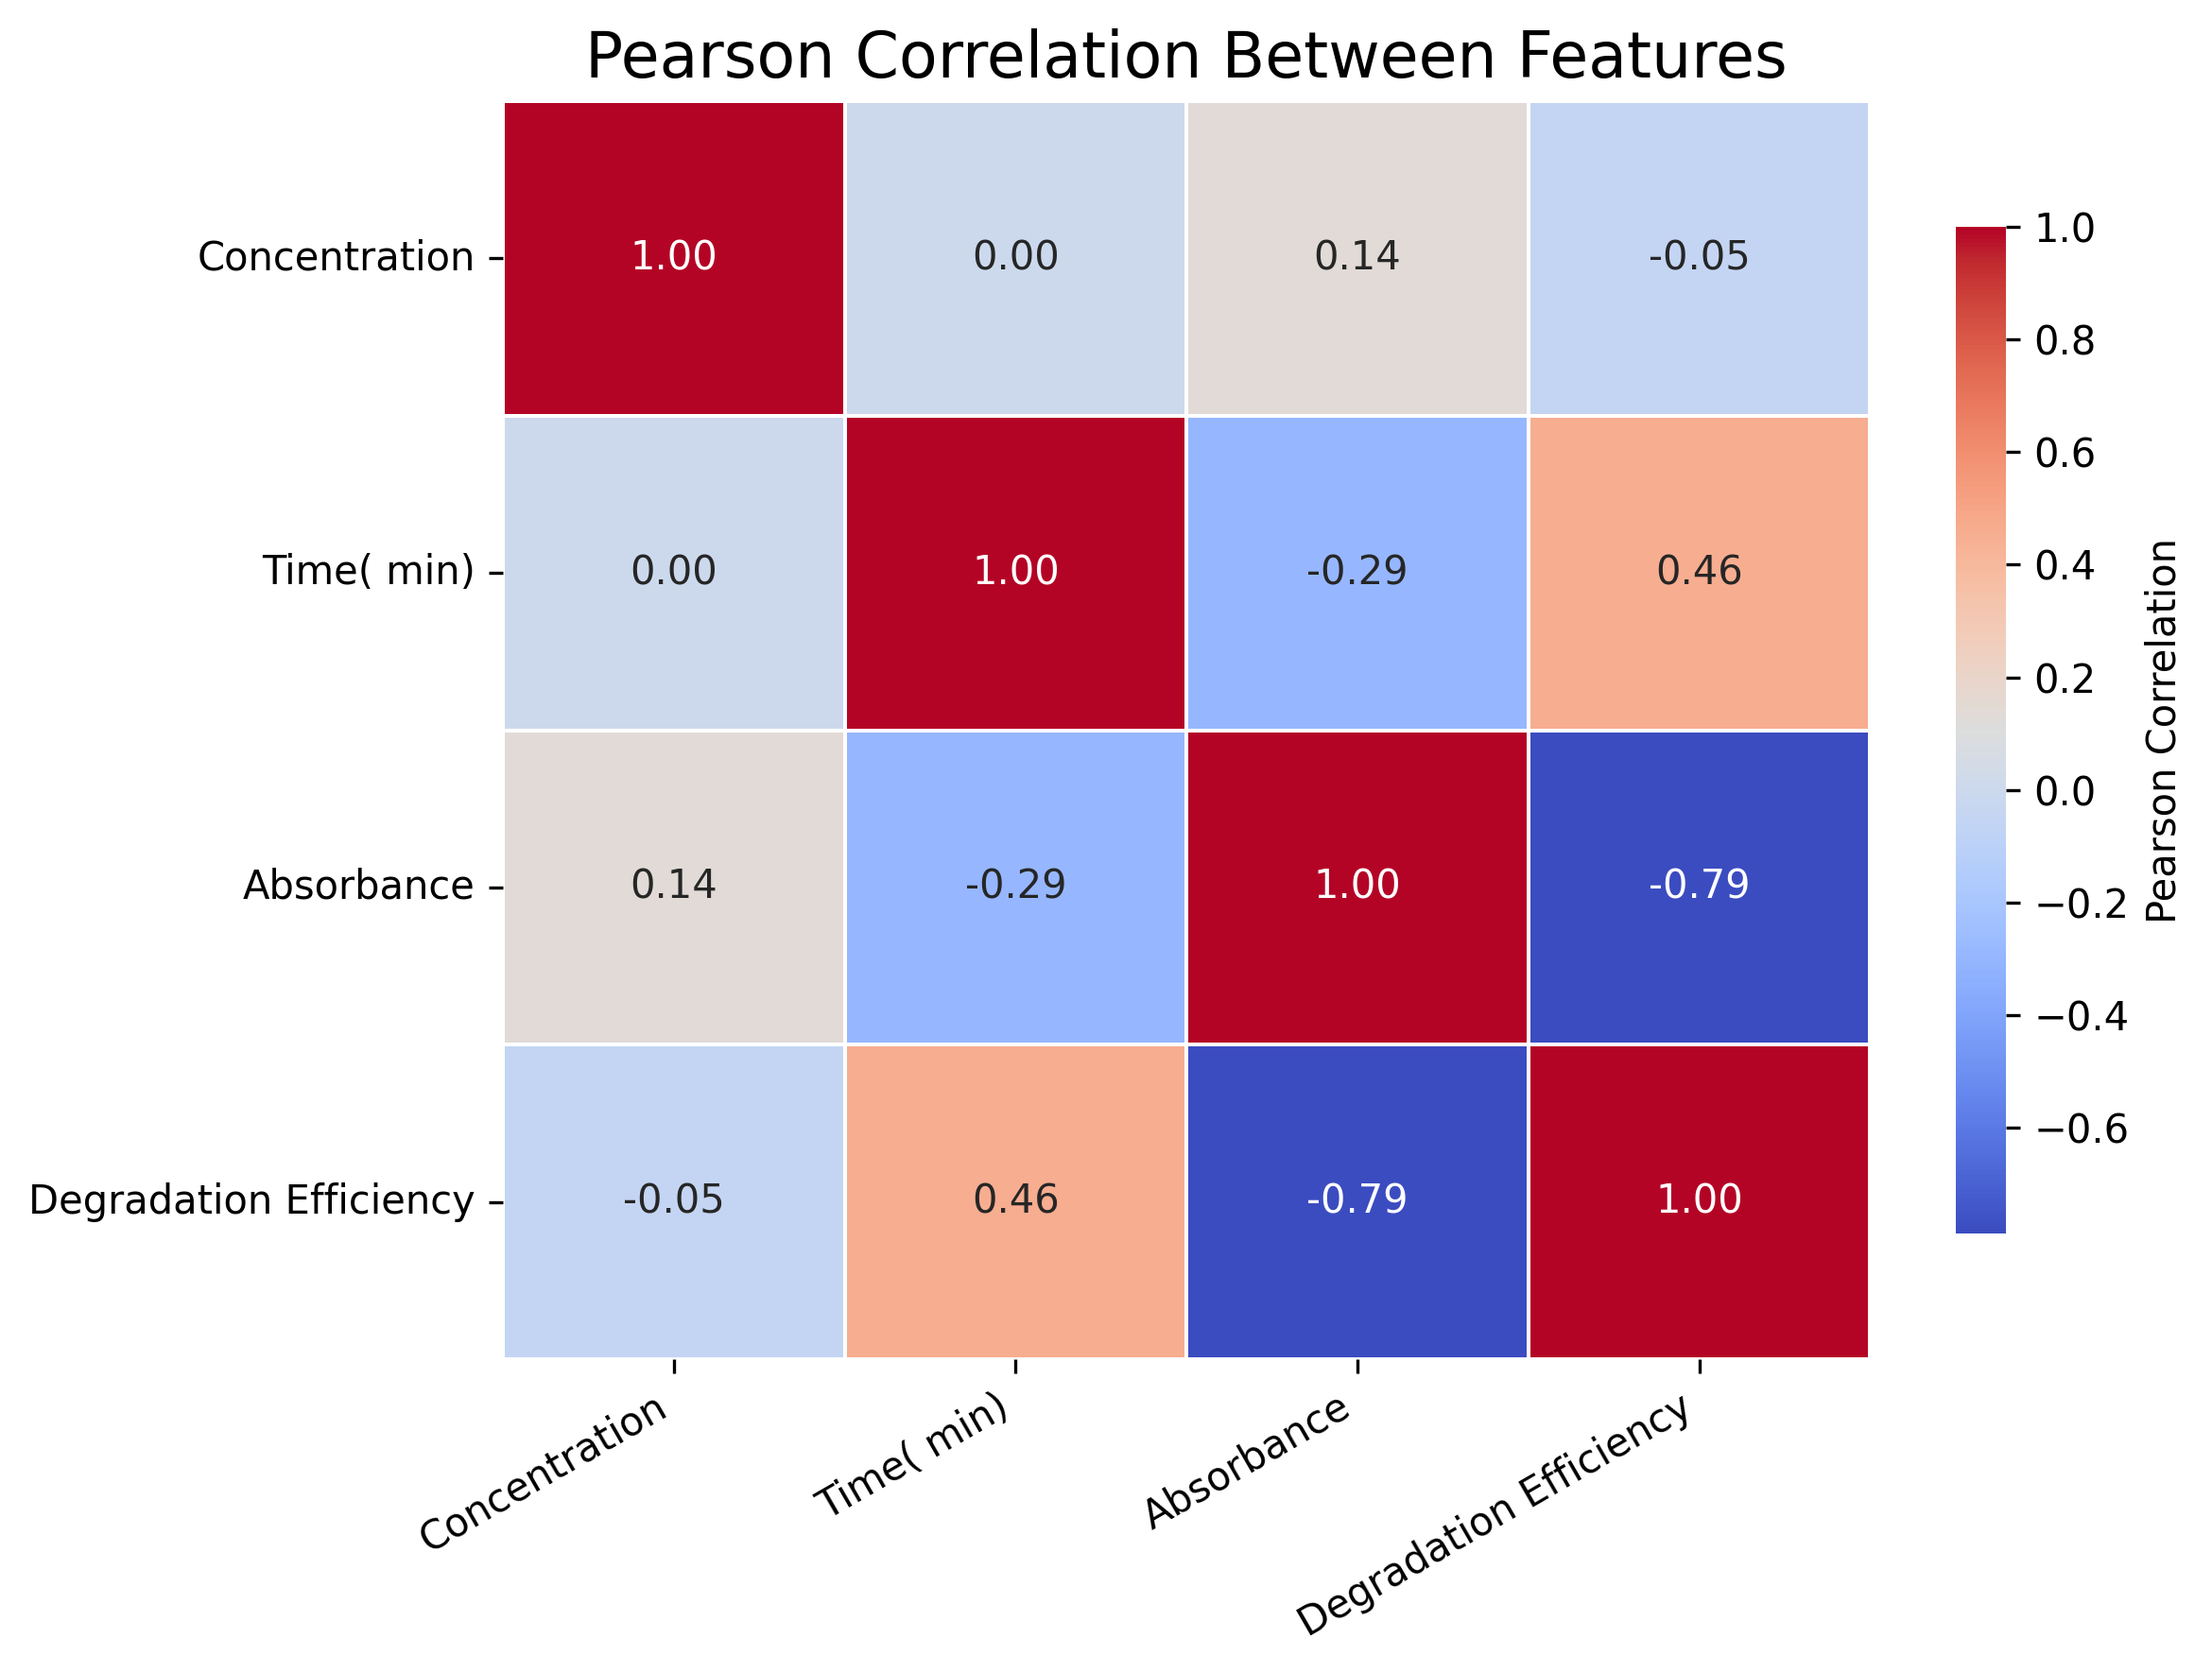

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop non-feature and target columns
features_df = df.drop(columns=["Nanomaterials Name"])

# Calculate Pearson correlation
corr_matrix = features_df.corr(method="pearson")

# Customization options
fig_width = 8      # Width in inches
fig_height = 6    # Height in inches
dpi_value = 300      # DPI (resolution)
cmap_style = "coolwarm"  # Color map
annot = True         # Show correlation numbers
fmt = ".2f"          # Number format
line_width = 0.5     # Lines between squares
cbar_shrink = 0.8    # Color bar size
label_rotation_x = 30
label_rotation_y = 0

# Create figure with custom size and DPI
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi_value)

# Plot full heatmap
sns.heatmap(
    corr_matrix,
    annot=annot,
    cmap=cmap_style,
    fmt=fmt,
    linewidths=line_width,
    cbar_kws={"shrink": cbar_shrink, "label": "Pearson Correlation"},
    ax=ax
)

# Customize labels
plt.xticks(rotation=label_rotation_x, ha="right")
plt.yticks(rotation=label_rotation_y)
plt.title("Pearson Correlation Between Features", fontsize=16)
plt.tight_layout()
plt.show()




In [4]:
# Features: all numeric columns except Nanomaterial Name and target
X = df.drop(columns=["Nanomaterials Name", "Degradation Efficiency"])

# Target variable
y = df["Degradation Efficiency"]



In [5]:
# Keep sample IDs
sample_ids = df["Nanomaterials Name"].values  # first column with sample names

# Split features, target, and sample IDs together
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, sample_ids, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")


Training samples: 316
Test samples: 80


In [6]:
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# Model initialization
rf = RandomForestRegressor(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200,300],
    'max_depth': [10, 15, 2],
    'min_samples_split': [2, 5,10],
    'min_samples_leaf': [1, 2,4],
    
    
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model selection
best_rf_model = grid_search.best_estimator_

# Predictions
y_train_pred_rf = best_rf_model.predict(X_train_scaled)
y_test_pred_rf = best_rf_model.predict(X_test_scaled)

# Step 6: Cross-validated predictions on training set (for Q²)
y_cv_pred = cross_val_predict(best_rf_model, X_train_scaled, y_train, cv=5)

# Evaluation metrics
# --- Train Set ---
r2_train = r2_score(y_train, y_train_pred_rf)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
mae_train = mean_absolute_error(y_train, y_train_pred_rf)

# --- Test Set ---
r2_test = r2_score(y_test, y_test_pred_rf)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_test = mean_absolute_error(y_test, y_test_pred_rf)

# --- Cross-Validation ---
neg_mse_cv_scores = cross_val_score(best_rf_model, X_train_scaled, y_train, scoring='neg_mean_squared_error', cv=5)
rmse_cv = np.mean(np.sqrt(-neg_mse_cv_scores))  # RMSECV
q2 = r2_score(y_train, y_cv_pred)  # Q²

Model Random Forest Regressor
🔧 Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📊 Train Set Metrics:
R² Train:  0.9975
RMSE Train: 0.0129
MAE Train:  0.0085

📈 Test Set Metrics:
R² Test:  0.9755
RMSE Test: 0.0357
MAE Test:  0.0259

🔁 Cross-Validation Metrics:
Q² (Cross-validated R²): 0.9846
RMSECV: 0.0320


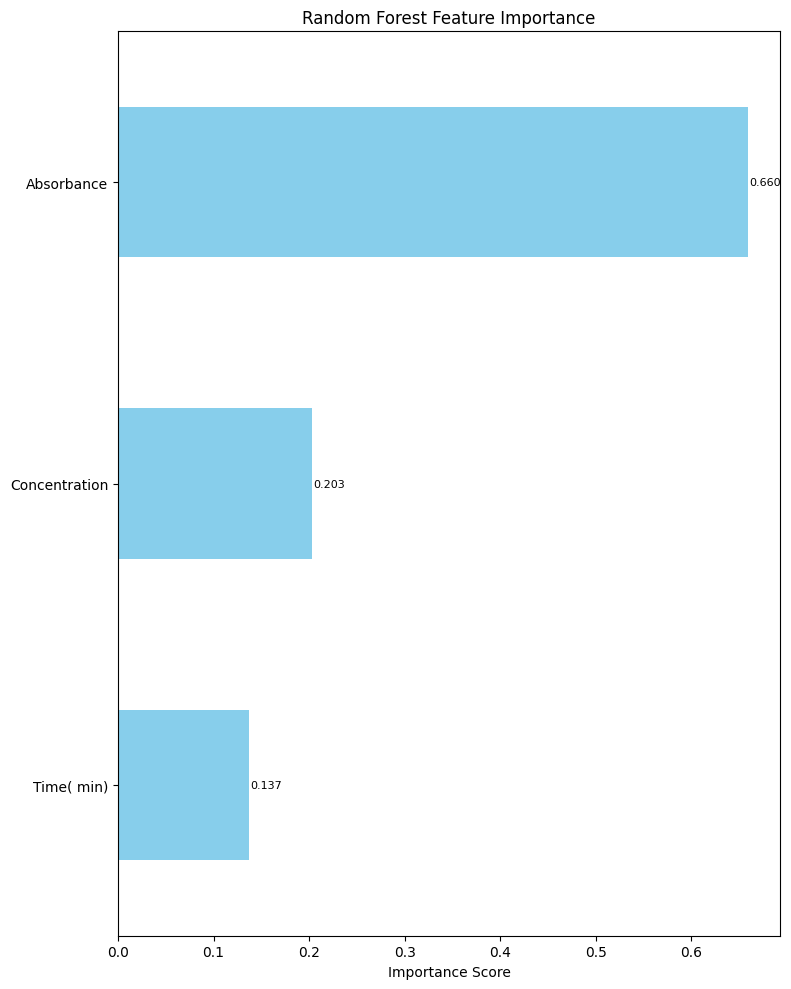

In [34]:

print("Model Random Forest Regressor")
print("🔧 Best Parameters:", grid_search.best_params_)
print("\n📊 Train Set Metrics:")
print(f"R² Train:  {r2_train:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"MAE Train:  {mae_train:.4f}")

print("\n📈 Test Set Metrics:")
print(f"R² Test:  {r2_test:.4f}")
print(f"RMSE Test: {rmse_test:.4f}")
print(f"MAE Test:  {mae_test:.4f}")

print("\n🔁 Cross-Validation Metrics:")
print(f"Q² (Cross-validated R²): {q2:.4f}")
print(f"RMSECV: {rmse_cv:.4f}")

# Feature Importance
importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=True)


# Plot with scale and value labels
plt.figure(figsize=(8, 10))
ax = importances_sorted.plot(kind='barh', color='skyblue')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()

# Add scale (value labels)
for i, v in enumerate(importances_sorted):
    ax.text(v + 0.001, i, f"{v:.3f}", va='center', fontsize=8)

plt.show()

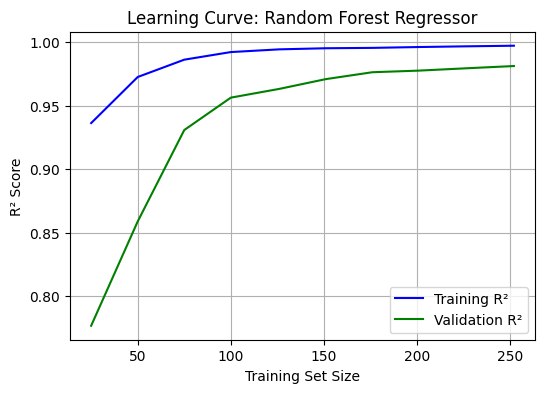

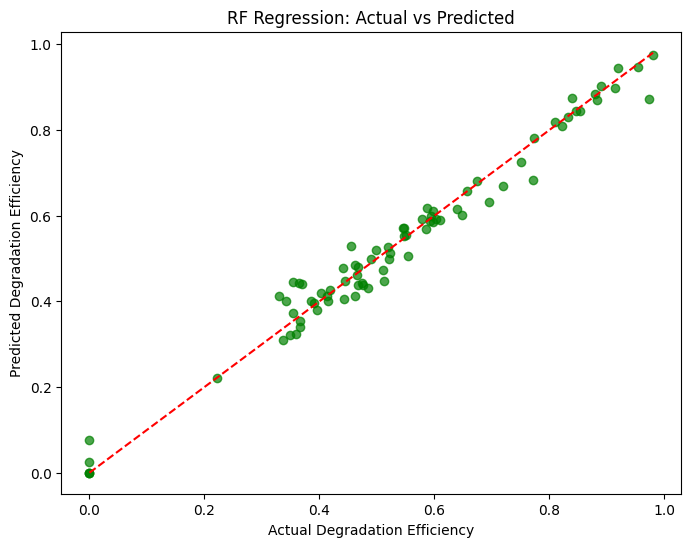

In [35]:
from sklearn.model_selection import learning_curve, KFold


#  Cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#  Compute learning curve using your trained model
train_sizes, train_scores, val_scores = learning_curve(
    best_rf_model,
    X_train_scaled,  # or X_train if unscaled
    y_train,
    cv=kf,
    scoring='r2',  # regression
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

#  Compute mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

#  Plot learning curve
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, label='Training R²', color='blue')
plt.plot(train_sizes, val_mean, label='Validation R²', color='green')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve: Random Forest Regressor')
plt.legend()
plt.grid(True)
plt.show()


#  Optional: Actual vs Predicted plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_rf, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Degradation Efficiency")
plt.ylabel("Predicted Degradation Efficiency")
plt.title("RF Regression: Actual vs Predicted")
plt.show()


In [36]:
import shap


# Create SHAP explainer (tree-based)
explainer_rf = shap.Explainer(best_rf_model)  # best_model is your trained RF model
shap_values_rf = explainer_rf(X_test)

# Summary plot
shap.summary_plot(shap_values_rf, X_test, plot_type="bar", show=True)
shap.summary_plot(shap_values_rf, X_test, show=True)

ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best SVR Parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
📊 Train Set: R²=0.7518, RMSE=0.1299, MAE=0.0804
📈 Test Set: R²=0.6749, RMSE=0.1300, MAE=0.0809
🔁 Cross-Validation: Q²=0.7357, RMSECV=0.1340


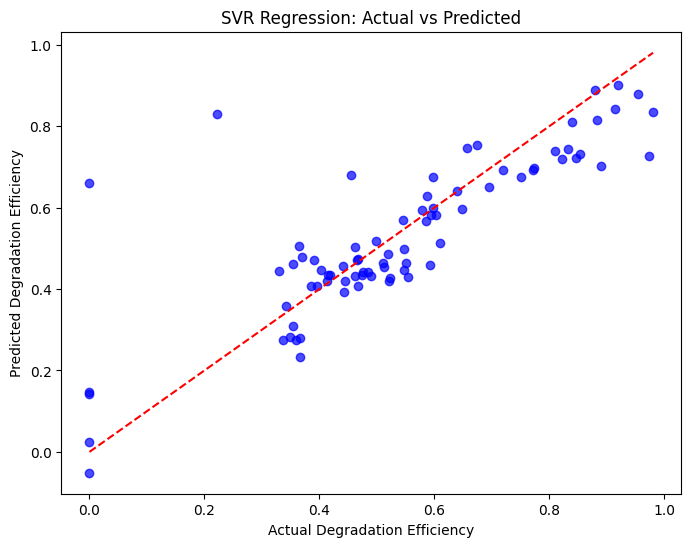

In [37]:


from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error



#  SVR model + hyperparameter grid
svr = SVR()
param_grid = {
    'kernel': ['rbf'],
    'C': [1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
    'epsilon': [0.1, 1]
}

grid_search = GridSearchCV(
    svr, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2
)
grid_search.fit(X_train_scaled, y_train)

# Best model
best_svr_model = grid_search.best_estimator_
print("Best SVR Parameters:", grid_search.best_params_)

#  Predictions
y_train_pred_svr = best_svr_model.predict(X_train_scaled)
y_test_pred_svr = best_svr_model.predict(X_test_scaled)

# Cross-validated predictions for Q²
y_cv_pred = cross_val_predict(best_svr_model, X_train_scaled, y_train, cv=5)

# Evaluation metrics
# --- Train ---
r2_train = r2_score(y_train, y_train_pred_svr)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_svr))
mae_train = mean_absolute_error(y_train, y_train_pred_svr)

# --- Test ---
r2_test = r2_score(y_test, y_test_pred_svr)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_svr))
mae_test = mean_absolute_error(y_test, y_test_pred_svr)

# --- Cross-Validation ---
rmse_cv = np.sqrt(mean_squared_error(y_train, y_cv_pred))
q2 = r2_score(y_train, y_cv_pred)

#  Print metrics
print(f"📊 Train Set: R²={r2_train:.4f}, RMSE={rmse_train:.4f}, MAE={mae_train:.4f}")
print(f"📈 Test Set: R²={r2_test:.4f}, RMSE={rmse_test:.4f}, MAE={mae_test:.4f}")
print(f"🔁 Cross-Validation: Q²={q2:.4f}, RMSECV={rmse_cv:.4f}")

#  Optional: Actual vs Predicted plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_svr, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Degradation Efficiency")
plt.ylabel("Predicted Degradation Efficiency")
plt.title("SVR Regression: Actual vs Predicted") 
plt.show() 


In [38]:
print("Model SVR")

print("🔧 Best Parameters:", grid_search.best_params_)

print("\n📊 Train Set Metrics:")
print(f"R² Train:  {r2_train:.4f}")
print(f"RMSE Train: {rmse_train:.4f}")
print(f"MAE Train:  {mae_train:.4f}")

print("\n📈 Test Set Metrics:")
print(f"R² Test:  {r2_test:.4f}")
print(f"RMSE Test: {rmse_test:.4f}")
print(f"MAE Test:  {mae_test:.4f}")

print("\n🔁 Cross-Validation Metrics:")
print(f"Q² (Cross-validated R²): {q2:.4f}")
print(f"RMSECV: {rmse_cv:.4f}")

Model SVR
🔧 Best Parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

📊 Train Set Metrics:
R² Train:  0.7518
RMSE Train: 0.1299
MAE Train:  0.0804

📈 Test Set Metrics:
R² Test:  0.6749
RMSE Test: 0.1300
MAE Test:  0.0809

🔁 Cross-Validation Metrics:
Q² (Cross-validated R²): 0.7357
RMSECV: 0.1340


In [41]:
from xgboost import XGBRegressor


#Model initialization
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

#Parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200,300],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1,2]
}

#Grid search with 5-fold cross-validation
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

#Best model selection
best_xg_model = grid_search.best_estimator_

#Predictions
y_train_pred_xg = best_xg_model.predict(X_train_scaled)
y_test_pred_xg = best_xg_model.predict(X_test_scaled)

#Cross-validated predictions on training set (for Q²)
y_cv_pred = cross_val_predict(best_xg_model, X_train_scaled, y_train, cv=5)

#Evaluation metrics
# --- Train Set ---
r2_train = r2_score(y_train, y_train_pred_xg)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_xg))
mae_train = mean_absolute_error(y_train, y_train_pred_xg)

# --- Test Set ---
r2_test = r2_score(y_test, y_test_pred_xg)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_xg))
mae_test = mean_absolute_error(y_test, y_test_pred_xg)

# --- Cross-Validation ---
neg_mse_cv_scores = cross_val_score(best_xg_model, X_train_scaled, y_train, scoring='neg_mean_squared_error', cv=5)
rmse_cv = np.mean(np.sqrt(-neg_mse_cv_scores))  # RMSECV
q2 = r2_score(y_train, y_cv_pred)  # Q²


In [42]:
print("Model XGBoost Regressor")
print("===== Train Set Metrics =====")
print(f"R² (Train): {r2_train:.4f}")
print(f"RMSE (Train): {rmse_train:.4f}")
print(f"MAE (Train): {mae_train:.4f}")

print("\n===== Test Set Metrics =====")
print(f"R² (Test): {r2_test:.4f}")
print(f"RMSE (Test): {rmse_test:.4f}")
print(f"MAE (Test): {mae_test:.4f}")

print("\n===== Cross-Validation Metrics =====")
print(f"Q² (Cross-validated R²): {q2:.4f}")
print(f"RMSECV: {rmse_cv:.4f}")

print("\n===== Best Hyperparameters =====")
print(grid_search.best_params_)


Model XGBoost Regressor
===== Train Set Metrics =====
R² (Train): 0.9972
RMSE (Train): 0.0138
MAE (Train): 0.0102

===== Test Set Metrics =====
R² (Test): 0.9797
RMSE (Test): 0.0325
MAE (Test): 0.0240

===== Cross-Validation Metrics =====
Q² (Cross-validated R²): 0.9787
RMSECV: 0.0376

===== Best Hyperparameters =====
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.9}


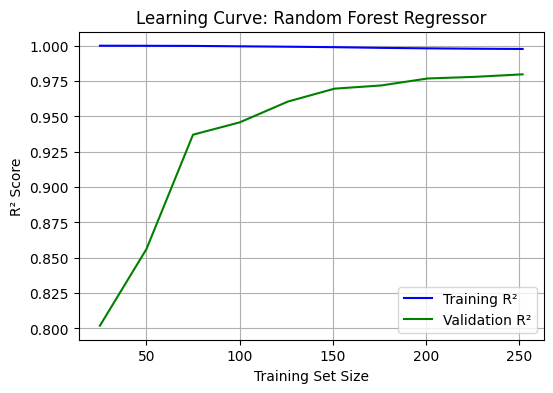

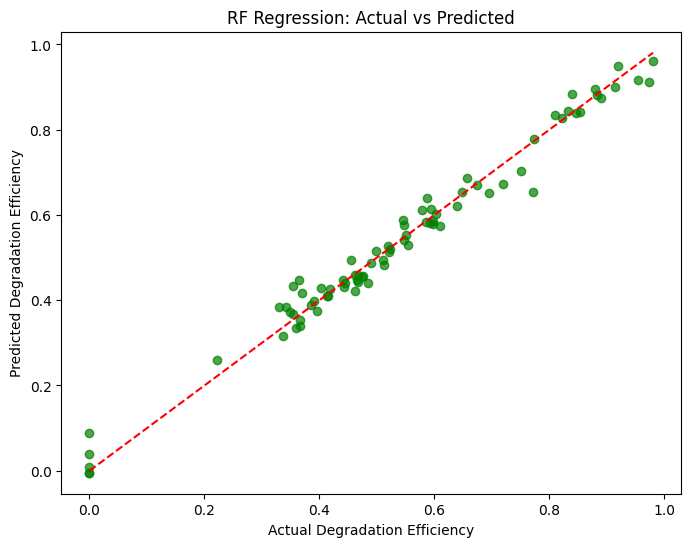

In [43]:
from sklearn.model_selection import learning_curve, KFold


#  Cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Compute learning curve using your trained model
train_sizes, train_scores, val_scores = learning_curve(
    best_xg_model,
    X_train_scaled,  # or X_train if unscaled
    y_train,
    cv=kf,
    scoring='r2',  # regression
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

#  Compute mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

#  Plot learning curve
plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, label='Training R²', color='blue')
plt.plot(train_sizes, val_mean, label='Validation R²', color='green')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve: Random Forest Regressor')
plt.legend()
plt.grid(True)
plt.show()


#  Optional: Actual vs Predicted plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_xg, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Degradation Efficiency")
plt.ylabel("Predicted Degradation Efficiency")
plt.title("RF Regression: Actual vs Predicted")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# --- Hyperparameter distribution ---
param_dist = {
    'hidden_layer_sizes': [(5,), (10,), (10,5), (20,10)],  # small layers
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    'learning_rate_init': [0.001, 0.01]
}

# --- RandomizedSearchCV ---
rand_search = RandomizedSearchCV(
    estimator=MLPRegressor(max_iter=5000, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# --- Fit search ---
rand_search.fit(X_train_scaled, y_train)

# --- Best estimator ---
best_mlp = rand_search.best_estimator_
print("Best Parameters:", rand_search.best_params_)

# --- Predictions ---
y_train_pred = best_mlp.predict(X_train_scaled)
y_test_pred = best_mlp.predict(X_test_scaled)

# --- Train metrics ---
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# --- Test metrics ---
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# --- Cross-validation metrics (on training set) ---
cv_r2_scores = cross_val_score(best_mlp, X_train_scaled, y_train, cv=5, scoring='r2')
cv_mse_scores = -cross_val_score(best_mlp, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

q2 = cv_r2_scores.mean()
rmsecv = np.sqrt(cv_mse_scores.mean())

# --- Print results ---
print("\n=== Train Set Metrics ===")
print(f"R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}")

print("\n=== Test Set Metrics ===")
print(f"R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}")

print("\n=== 5-Fold CV Metrics (on training set) ===")
print(f"Q² (mean R²): {q2:.4f}")
print(f"RMSECV: {rmsecv:.4f}")
print(f"R² (mean ± std): {cv_r2_scores.mean():.4f} ± {cv_r2_scores.std():.4f}")
print(f"MSE (mean ± std): {cv_mse_scores.mean():.4f} ± {cv_mse_scores.std():.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (5,), 'alpha': 0.0001, 'activation': 'tanh'}

=== Train Set Metrics ===
R²: 0.7104, RMSE: 0.1403, MAE: 0.0857

=== Test Set Metrics ===
R²: 0.6540, RMSE: 0.1341, MAE: 0.0829

=== 5-Fold CV Metrics (on training set) ===
Q² (mean R²): 0.7094
RMSECV: 0.1411
R² (mean ± std): 0.7094 ± 0.0541
MSE (mean ± std): 0.0199 ± 0.0052


In [45]:
import shap
import matplotlib.pyplot as plt

# SHAP explainer and values
explainer_xgb = shap.Explainer(best_rf_model)
shap_values_xgb = explainer_xgb(X_test)

# Set DPI globally and font
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.grid'] = False
plt.rcParams["font.family"] = "Times New Roman"

### -------- SHAP Bar Plot -------- ###
shap.summary_plot(shap_values_xgb, X_test, plot_type="dot", show=False, plot_size=(4, 3))

# Customize font after the plot is drawn
fig = plt.gcf()
ax = plt.gca()
ax.set_title("Feature Importance", fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Optional: control spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("shap_bar_plot.png", dpi=300, bbox_inches='tight')
plt.show()






ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.

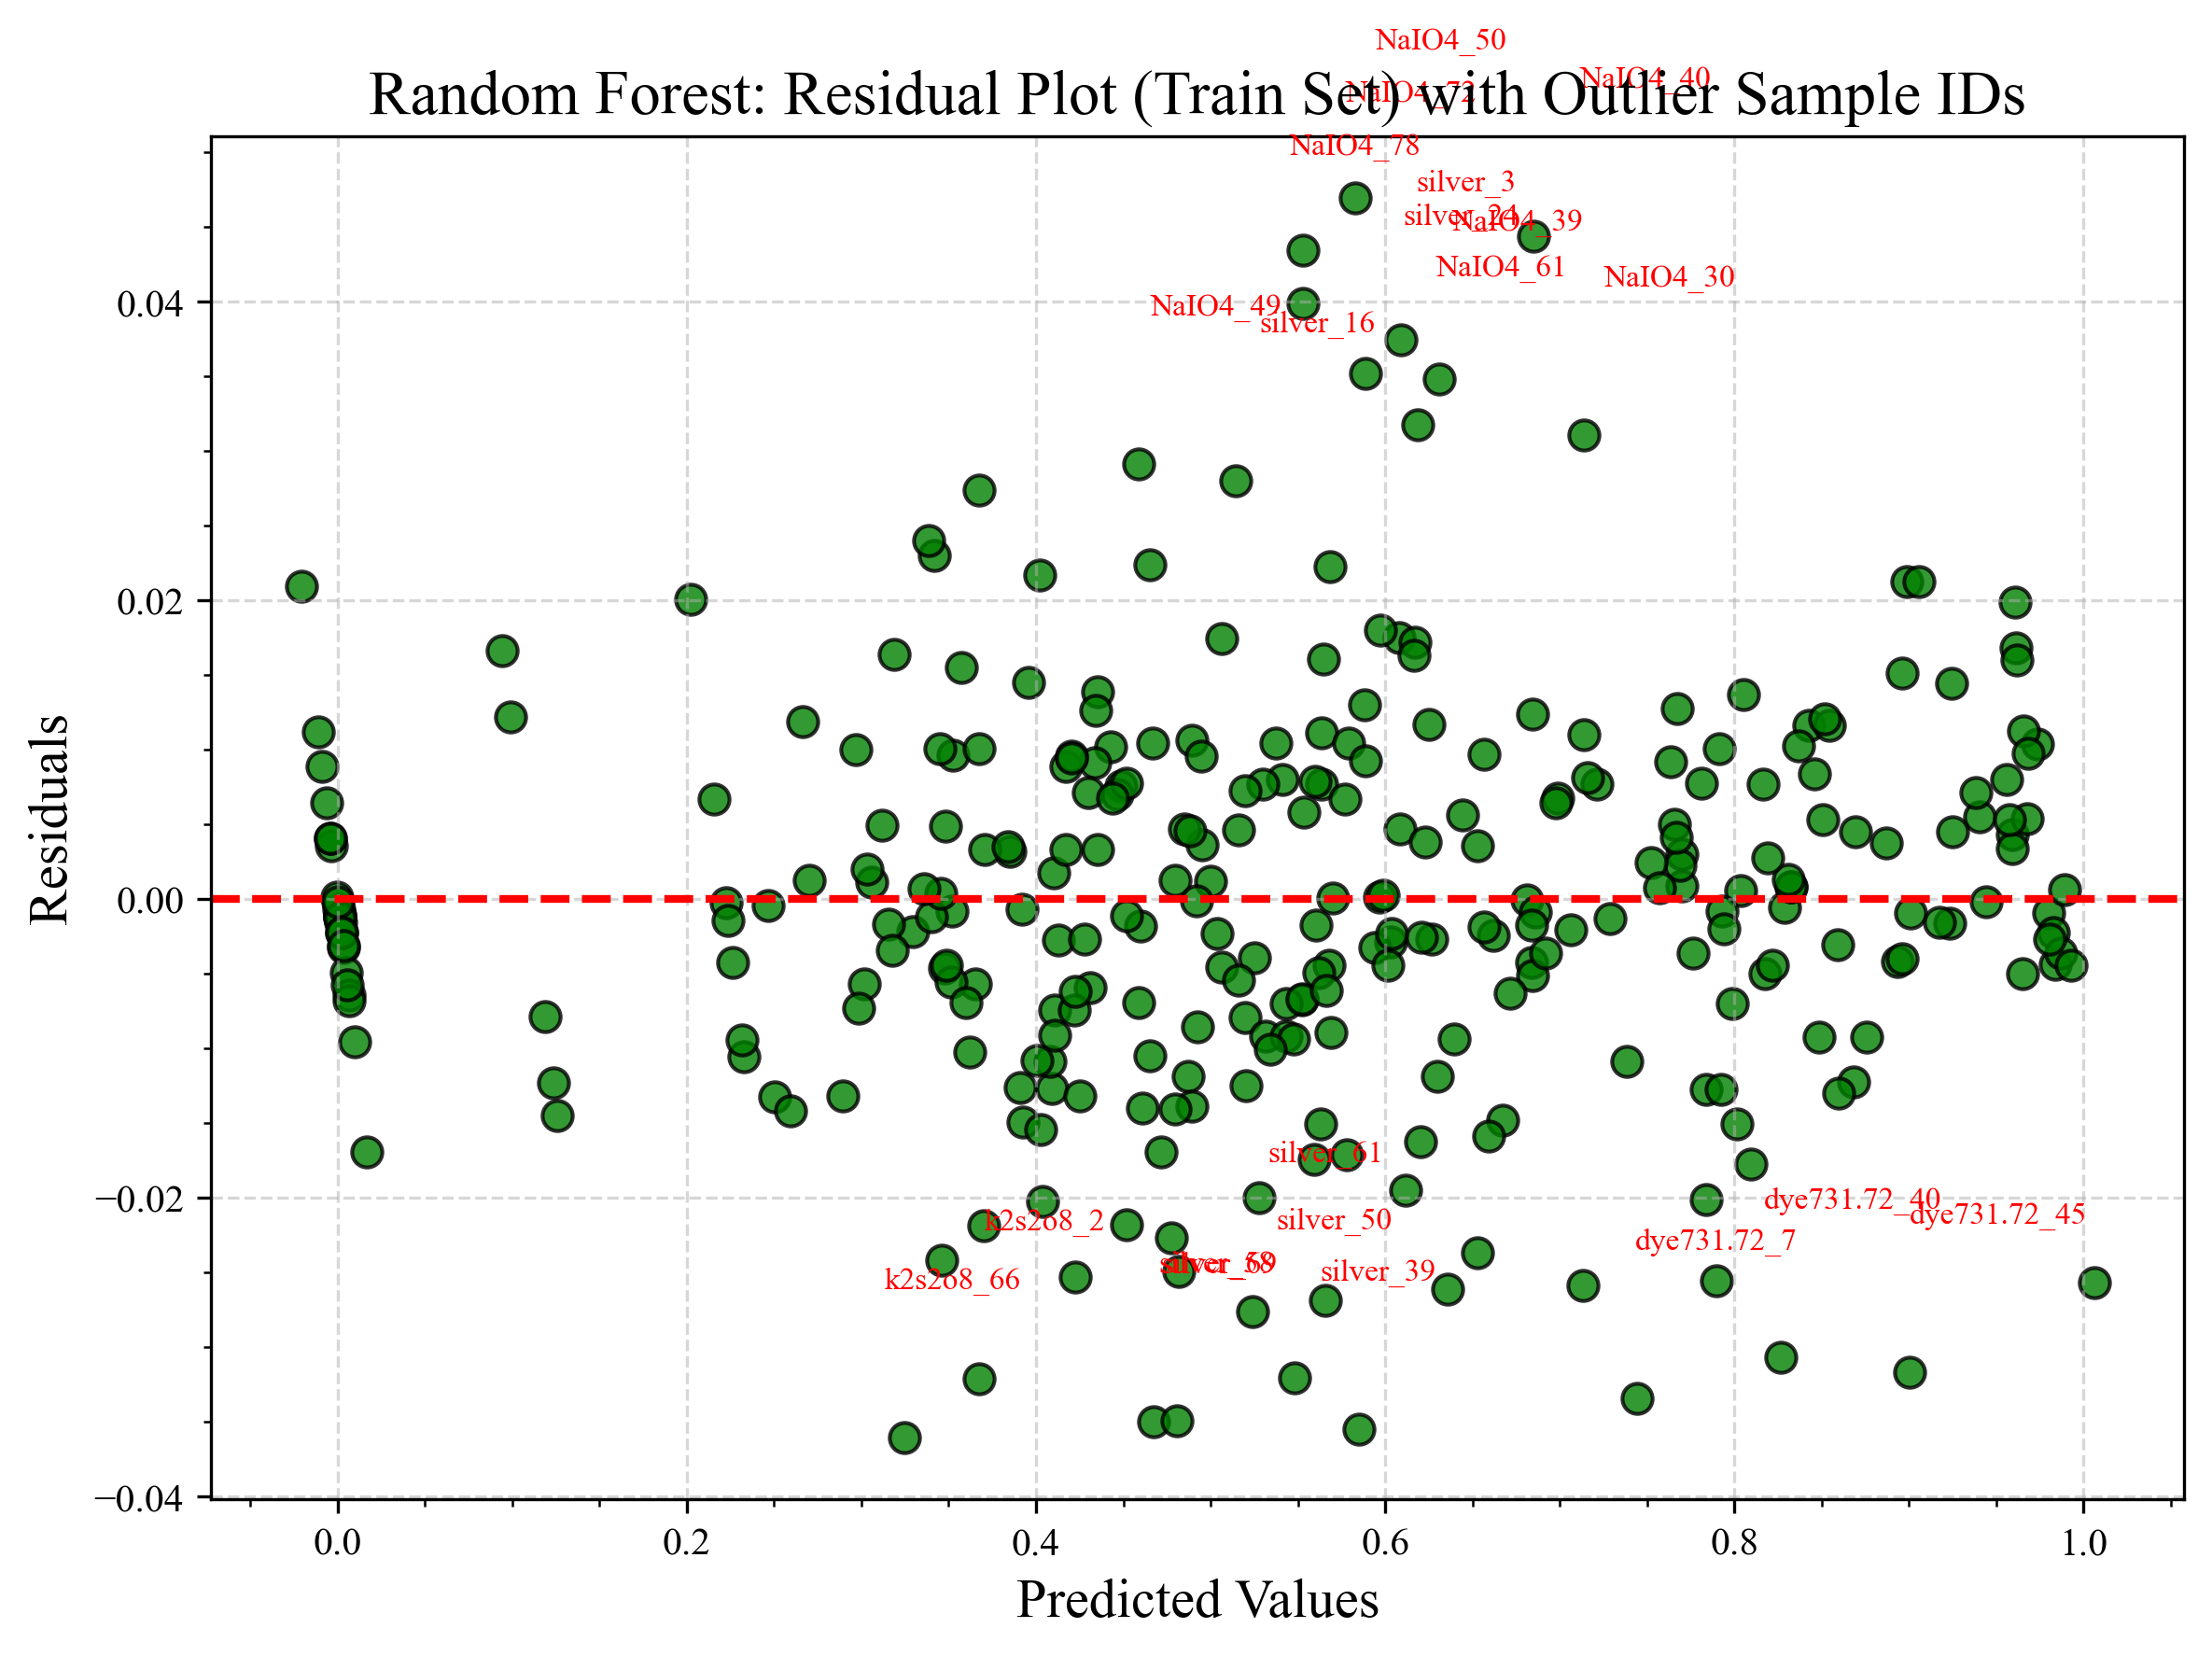

Residual Plot Outlier Sample IDs (Train Set):
['silver_16', 'NaIO4_40', 'silver_24', 'silver_61', 'silver_50', 'NaIO4_61', 'silver_69', 'NaIO4_30', 'k2s2o8_2', 'NaIO4_50', 'k2s2o8_66', 'NaIO4_49', 'silver_3', 'NaIO4_78', 'dye731.72_40', 'NaIO4_72', 'silver_39', 'dye731.72_45', 'silver_58', 'NaIO4_39', 'dye731.72_7']
Number of residual outliers in train set: 21


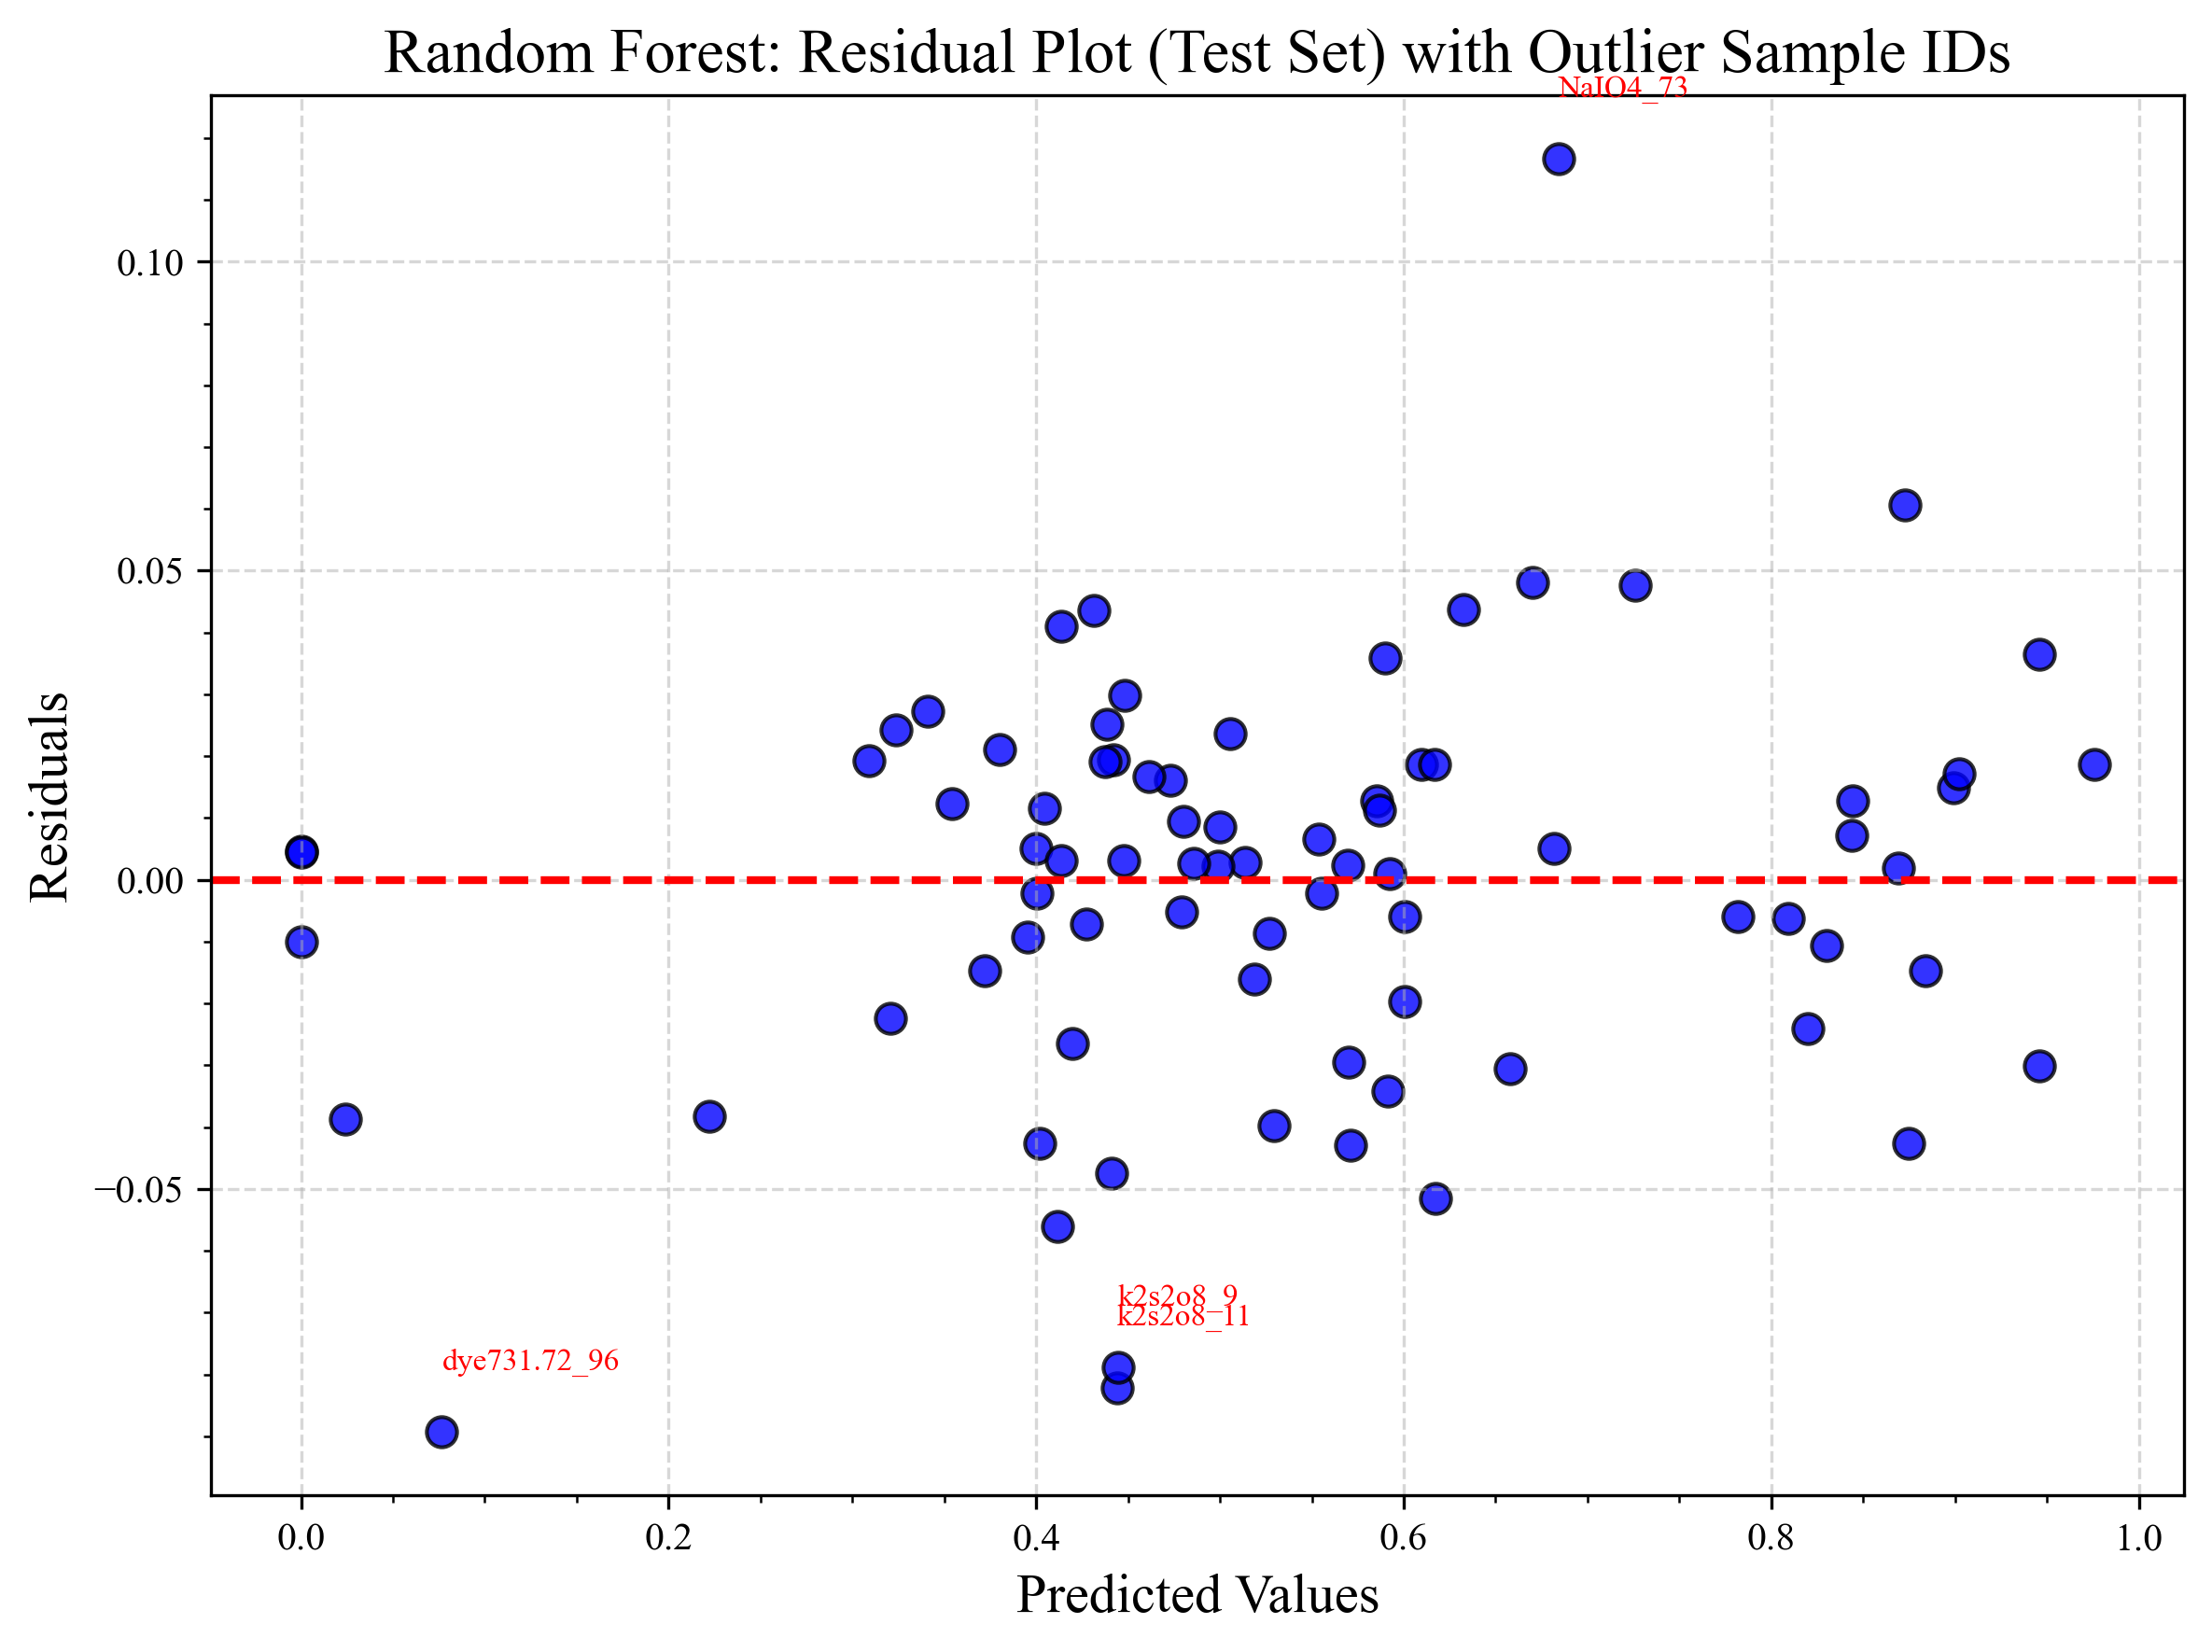

Residual Plot Outlier Sample IDs (Test Set):
['dye731.72_96', 'k2s2o8_11', 'k2s2o8_9', 'NaIO4_73']
Number of residual outliers in test set: 4


In [61]:
# --- Residual Plot (Train Set) with Outlier Sample IDs ---
residuals_train = y_train - y_train_pred_xg  # compute residuals

# Define outliers: absolute residual > 2*std
threshold_train = 2 * np.std(residuals_train)
outlier_mask_train = np.abs(residuals_train) > threshold_train

# Get sample IDs for train set
sample_ids_train_array = np.array(df.iloc[y_train.index, 0].values)

plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(y_train_pred_xg, residuals_train, c='green', edgecolors='black', s=60, alpha=0.8, marker='o')
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Label only outlier points
for i in np.where(outlier_mask_train)[0]:
    plt.text(y_train_pred_rf[i], residuals_train.iloc[i]+0.01,
             str(sample_ids_train_array[i]), fontsize=8, color='red')

plt.xlabel('Predicted Values', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.title('Random Forest: Residual Plot (Train Set) with Outlier Sample IDs', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.savefig("rf_train_residual_plot.png", dpi=300)
plt.show()

# Print outlier sample IDs for train set
outlier_sample_ids_train = sample_ids_train_array[outlier_mask_train]
print("Residual Plot Outlier Sample IDs (Train Set):")
print(outlier_sample_ids_train.tolist())
print("Number of residual outliers in train set:", len(outlier_sample_ids_train))


# --- Residual Plot (Test Set) with Outlier Sample IDs ---
residuals_test = y_test - y_test_pred_xg  # compute residuals

# Define outliers: absolute residual > 2*std
threshold_test = 2 * np.std(residuals_test)
outlier_mask_test = np.abs(residuals_test) > threshold_test

# Get sample IDs for test set
sample_ids_test_array = np.array(df.iloc[y_test.index, 0].values)

plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(y_test_pred_rf, residuals_test, c='blue', edgecolors='black', s=60, alpha=0.8, marker='o')
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# Label only outlier points
for i in np.where(outlier_mask_test)[0]:
    plt.text(y_test_pred_rf[i], residuals_test.iloc[i]+0.01,
             str(sample_ids_test_array[i]), fontsize=8, color='red')

plt.xlabel('Predicted Values', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.title('Random Forest: Residual Plot (Test Set) with Outlier Sample IDs', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tight_layout()
plt.savefig("xg_test_residual_plot.png", dpi=300)
plt.show()

# Print outlier sample IDs for test set
outlier_sample_ids_test = sample_ids_test_array[outlier_mask_test]
print("Residual Plot Outlier Sample IDs (Test Set):")
print(outlier_sample_ids_test.tolist())
print("Number of residual outliers in test set:", len(outlier_sample_ids_test))


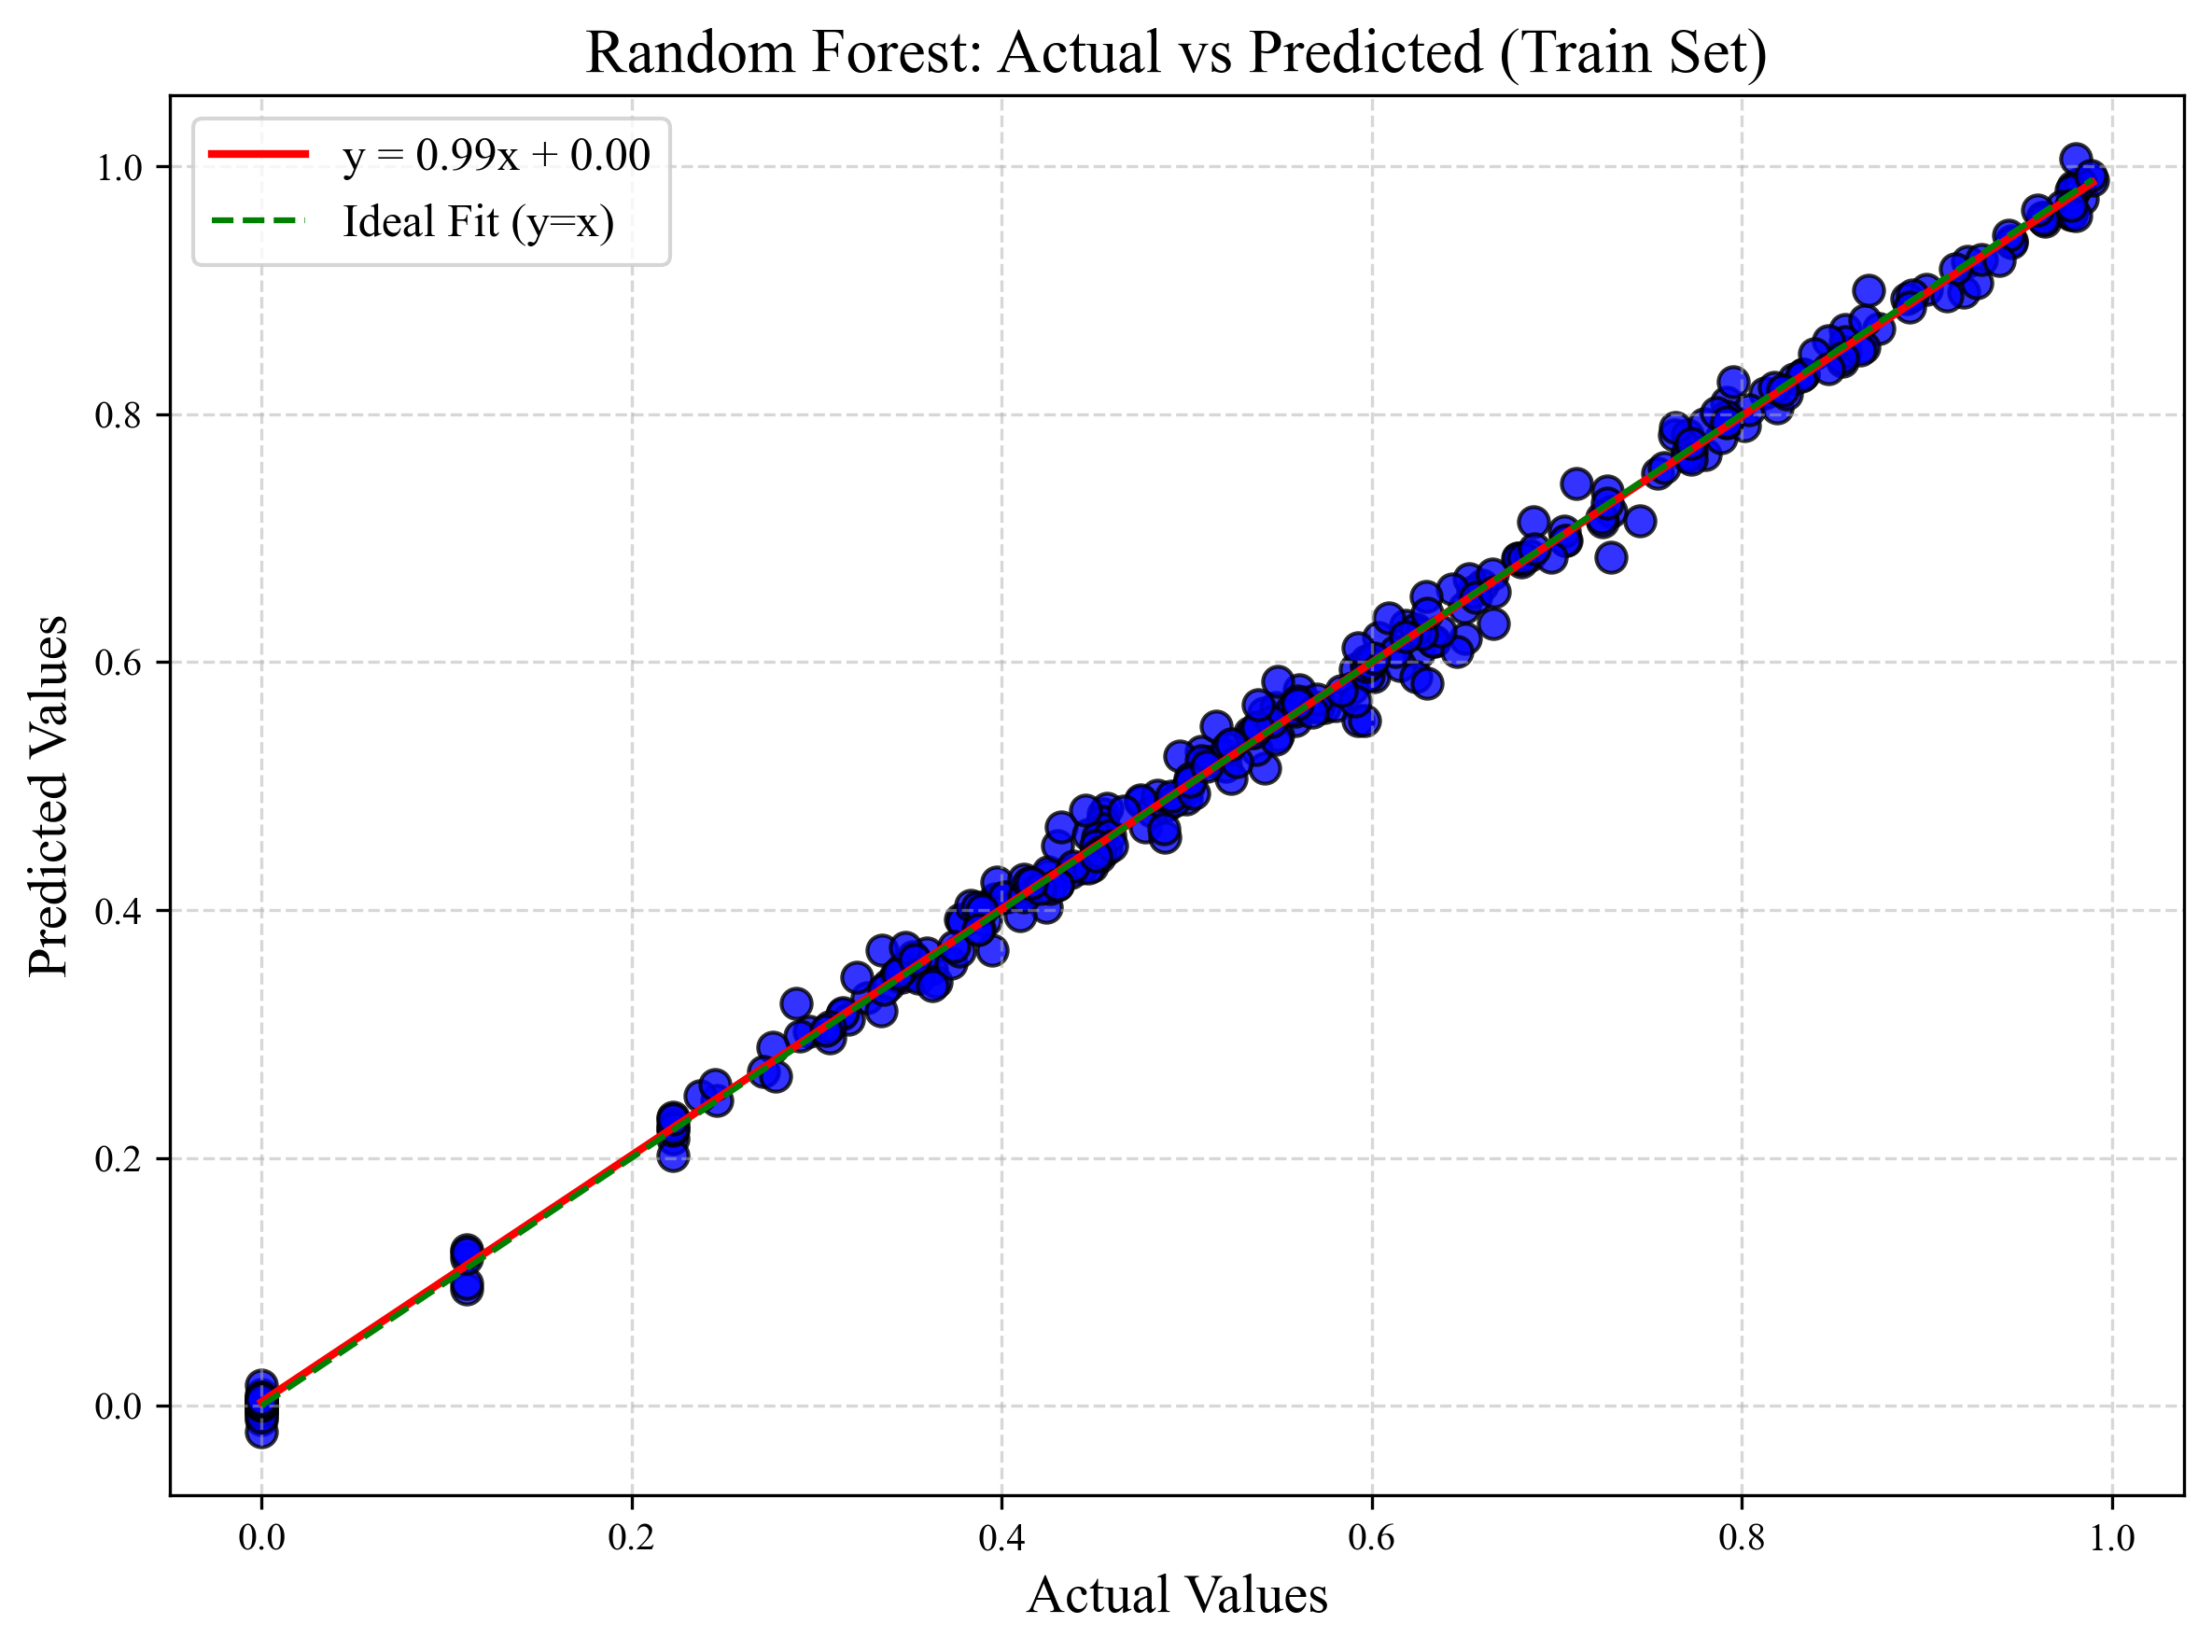

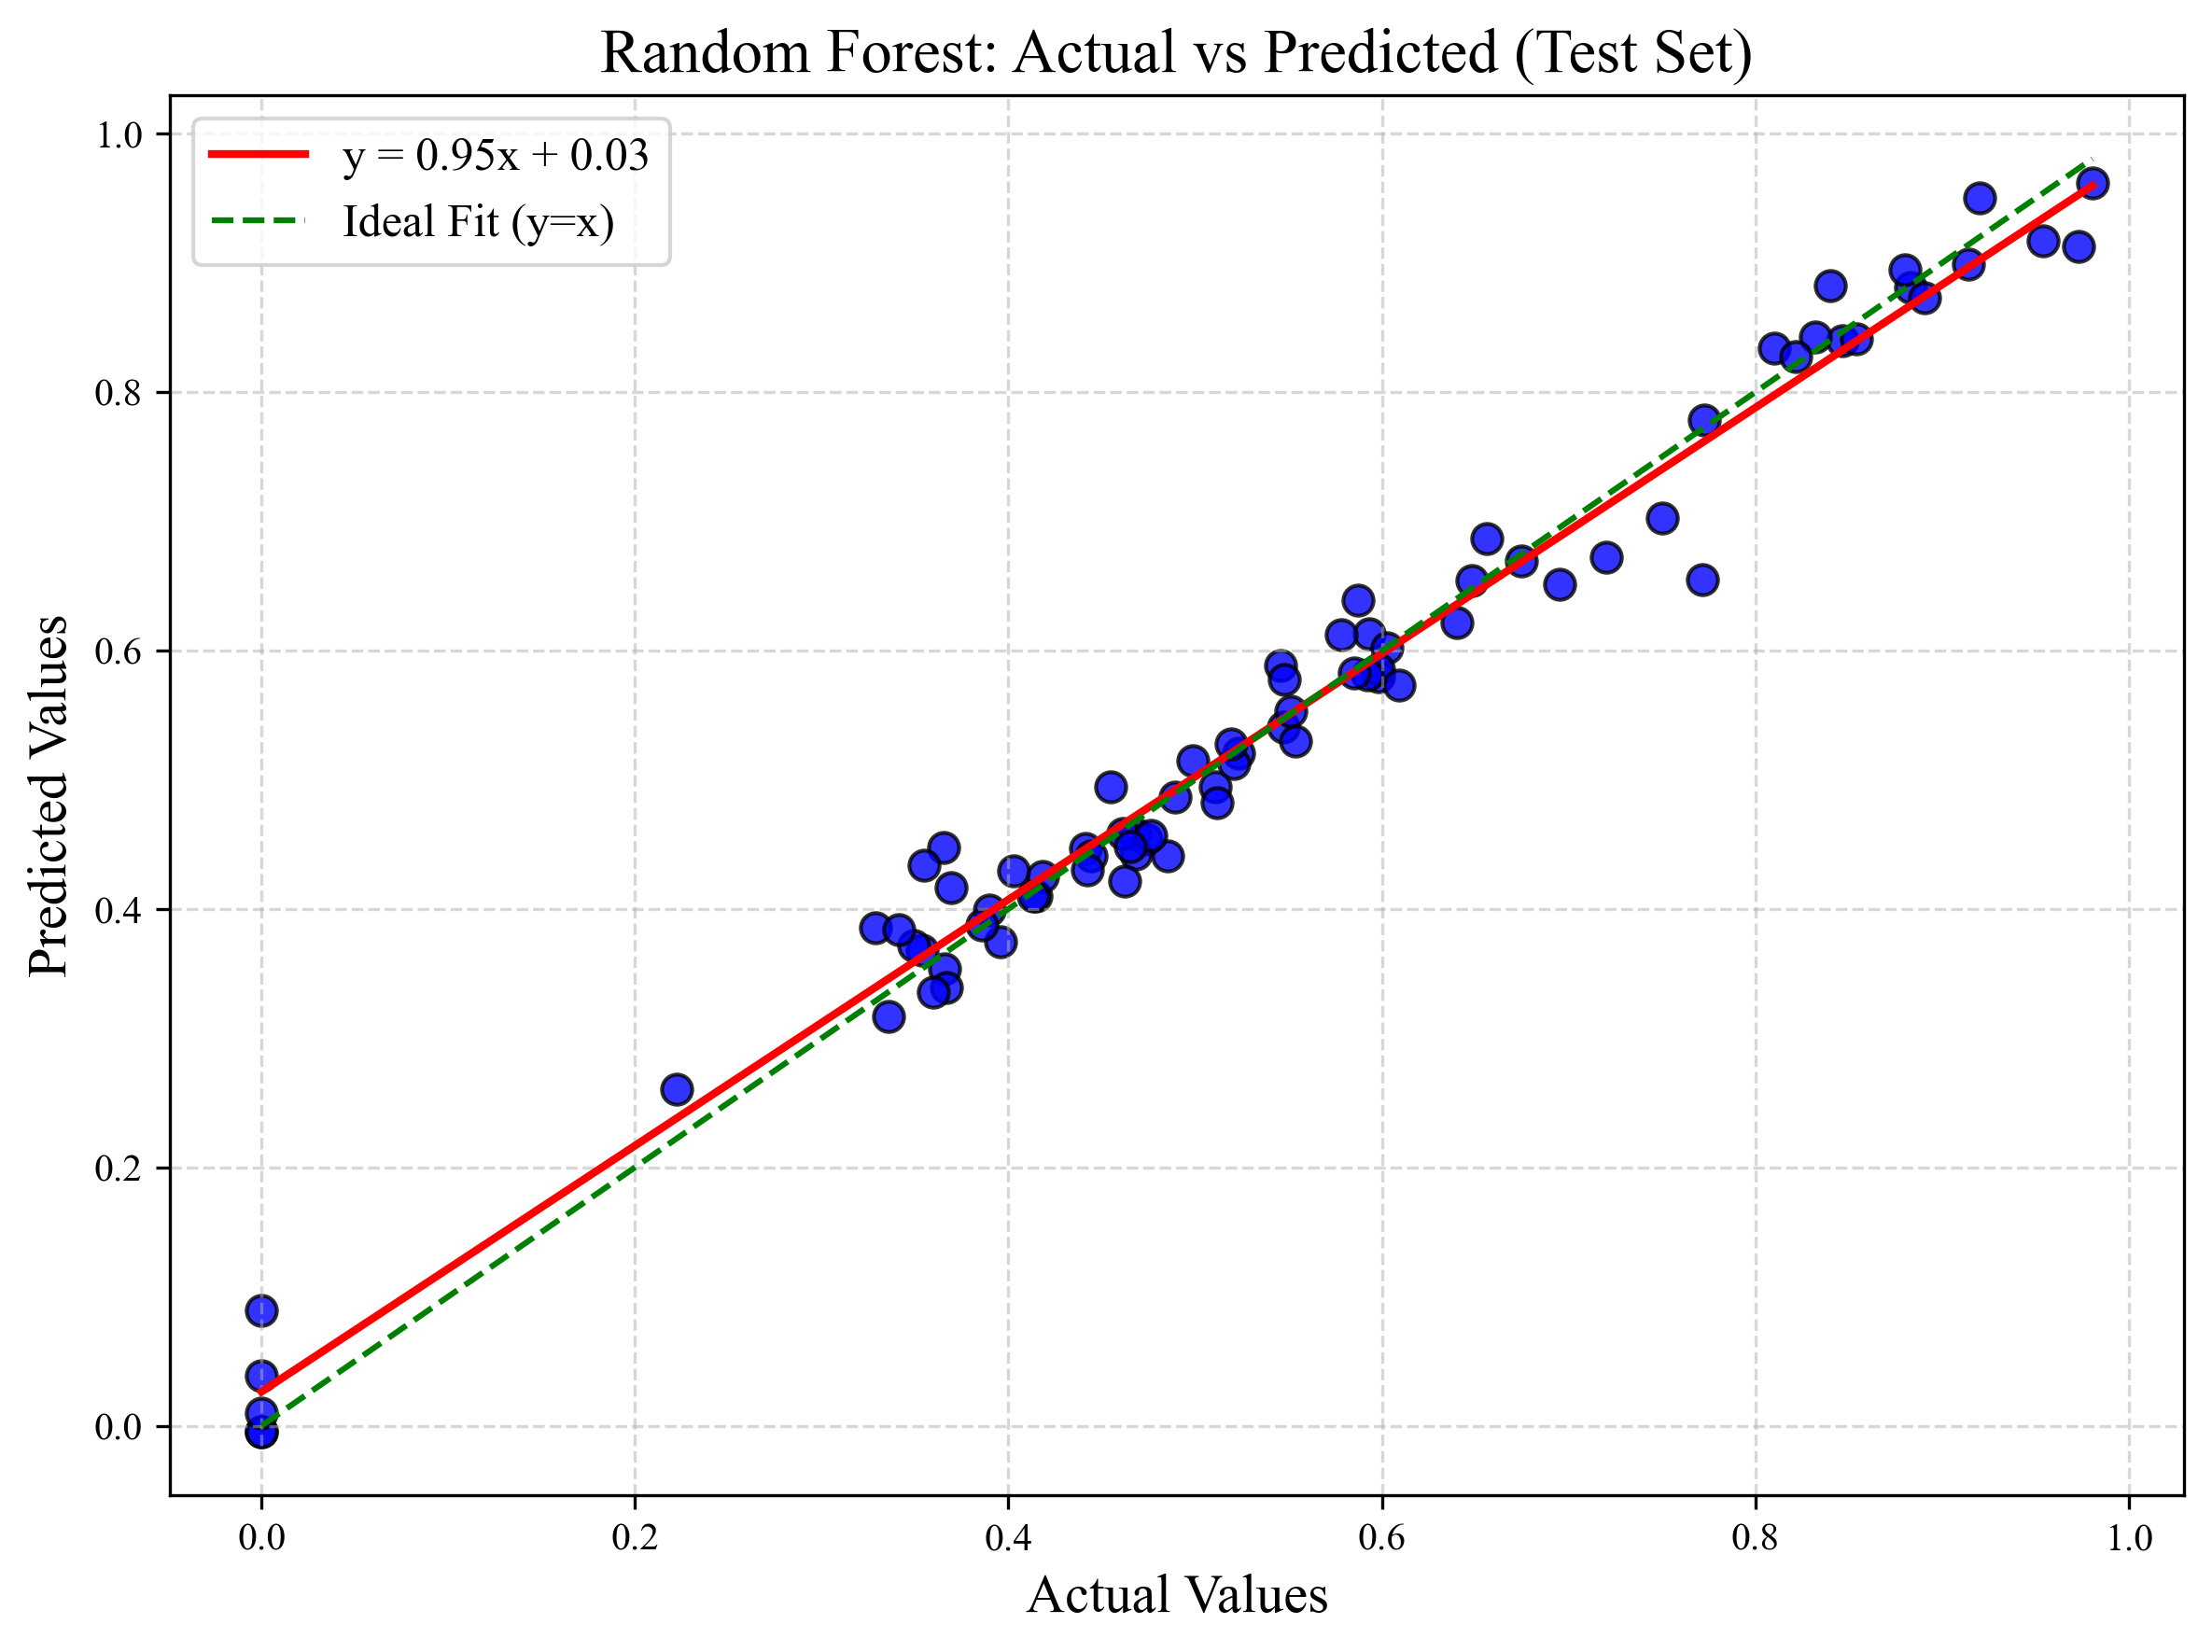

In [18]:
from sklearn.linear_model import LinearRegression

# --- Actual vs Predicted Plot (Train Set) ---
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(y_train, y_train_pred_xg, c='blue', edgecolors='black', s=60, alpha=0.8, marker='o')

# Fit regression line (y_pred = a*x + b)
reg_train = LinearRegression()
reg_train.fit(y_train.values.reshape(-1, 1), y_train_pred_xg)
line_x_train = np.linspace(y_train.min(), y_train.max(), 100)
line_y_train = reg_train.predict(line_x_train.reshape(-1, 1))

plt.plot(line_x_train, line_y_train, color="red", linewidth=2,
         label=f"y = {reg_train.coef_[0]:.2f}x + {reg_train.intercept_:.2f}")

# 45-degree reference line
plt.plot(line_x_train, line_x_train, color="green", linestyle="--", label="Ideal Fit (y=x)")

plt.xlabel("Actual Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("Random Forest: Actual vs Predicted (Train Set)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("xg_train_actual_vs_predicted.png", dpi=300)
plt.show()


# --- Actual vs Predicted Plot (Test Set) ---
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(y_test, y_test_pred_xg, c='blue', edgecolors='black', s=60, alpha=0.8, marker='o')

# Fit regression line (y_pred = a*x + b)
reg_test = LinearRegression()
reg_test.fit(y_test.values.reshape(-1, 1), y_test_pred_xg)
line_x_test = np.linspace(y_test.min(), y_test.max(), 100)
line_y_test = reg_test.predict(line_x_test.reshape(-1, 1))

plt.plot(line_x_test, line_y_test, color="red", linewidth=2,
         label=f"y = {reg_test.coef_[0]:.2f}x + {reg_test.intercept_:.2f}")

# 45-degree reference line
plt.plot(line_x_test, line_x_test, color="green", linestyle="--", label="Ideal Fit (y=x)")

plt.xlabel("Actual Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("Random Forest: Actual vs Predicted (Test Set)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("rf_test_actual_vs_predicted.png", dpi=300)
plt.show()


NameError: name 'sample_ids_train_array' is not defined

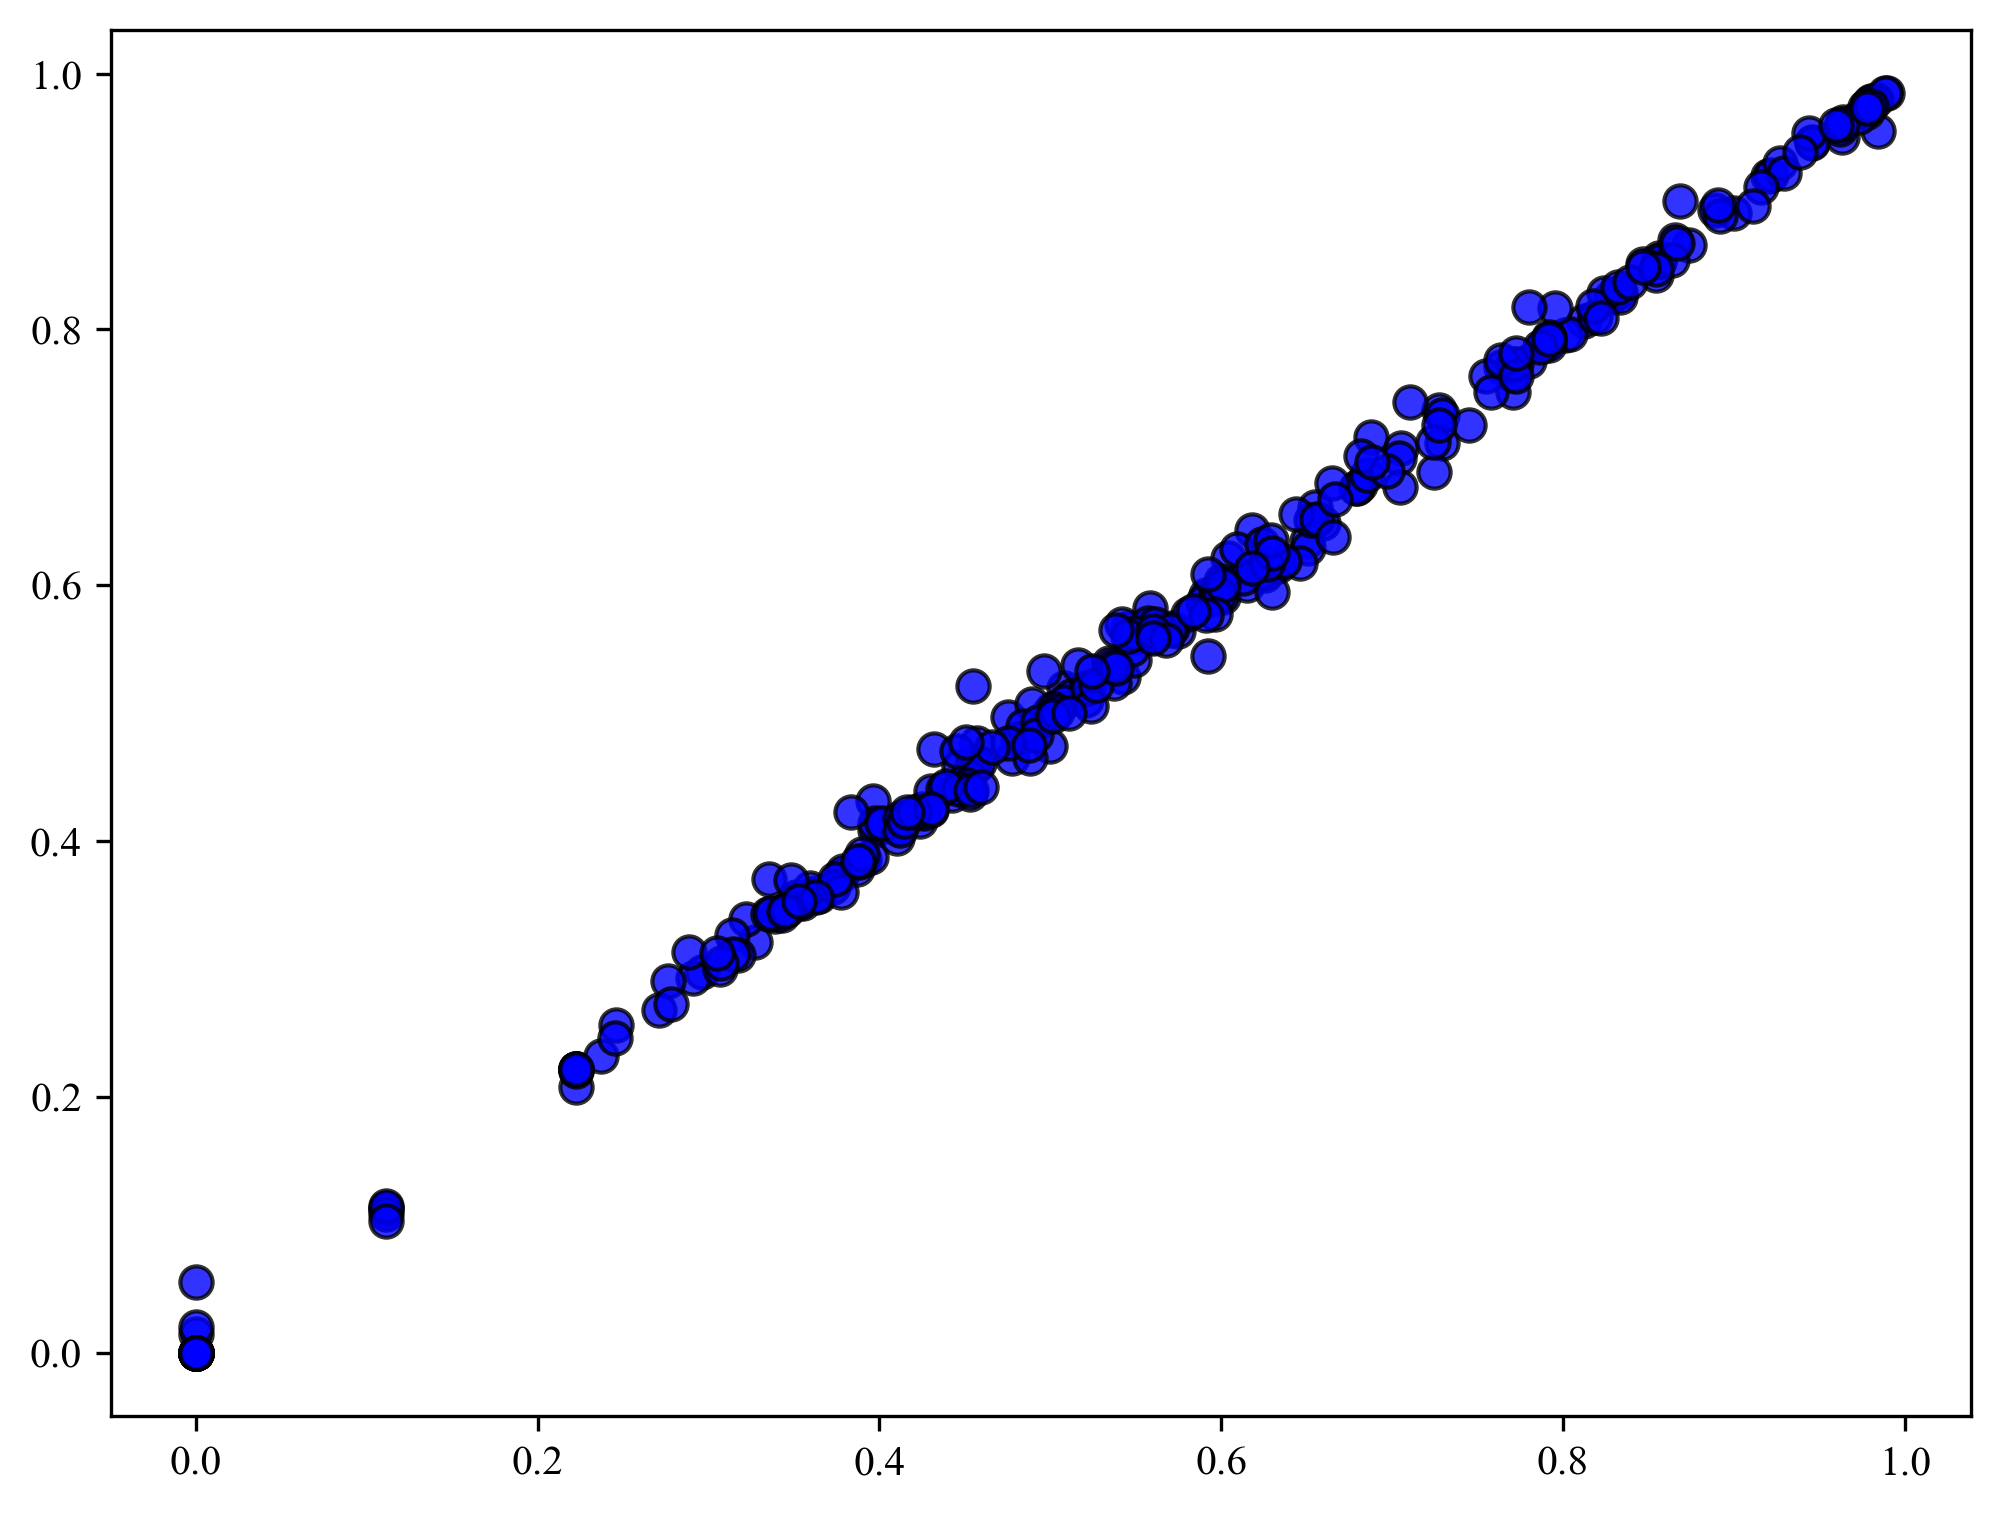

In [19]:
# --- Actual vs Predicted Plot (Train Set) with Sample IDs ---
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(y_train, y_train_pred_rf, c='blue', edgecolors='black', s=60, alpha=0.8, marker='o')

# Label each point with its sample ID
for i in range(len(y_train)):
    plt.text(y_train.iloc[i], y_train_pred_rf[i] + 0.01,   # shift label a bit up
             str(sample_ids_train_array[i]),
             fontsize=7, color='black', alpha=0.7, rotation=30)  # rotation optional

# Fit regression line (y_pred = a*x + b)
reg_train = LinearRegression()
reg_train.fit(y_train.values.reshape(-1, 1), y_train_pred_rf)
line_x_train = np.linspace(y_train.min(), y_train.max(), 100)
line_y_train = reg_train.predict(line_x_train.reshape(-1, 1))

plt.plot(line_x_train, line_y_train, color="red", linewidth=2,
         label=f"y = {reg_train.coef_[0]:.2f}x + {reg_train.intercept_:.2f}")

# 45-degree reference line
plt.plot(line_x_train, line_x_train, color="green", linestyle="--", label="Ideal Fit (y=x)")

plt.xlabel("Actual Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("Random Forest: Actual vs Predicted (Train Set)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("rf_train_actual_vs_predicted_with_ids.png", dpi=300)
plt.show()


# --- Actual vs Predicted Plot (Test Set) with Sample IDs ---
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(y_test, y_test_pred_rf, c='blue', edgecolors='black', s=60, alpha=0.8, marker='o')

# Label each point with its sample ID
for i in range(len(y_test)):
    plt.text(y_test.iloc[i], y_test_pred_rf[i] + 0.01,
             str(sample_ids_test_array[i]),
             fontsize=7, color='black', alpha=0.7, rotation=30)

# Fit regression line (y_pred = a*x + b)
reg_test = LinearRegression()
reg_test.fit(y_test.values.reshape(-1, 1), y_test_pred_rf)
line_x_test = np.linspace(y_test.min(), y_test.max(), 100)
line_y_test = reg_test.predict(line_x_test.reshape(-1, 1))

plt.plot(line_x_test, line_y_test, color="red", linewidth=2,
         label=f"y = {reg_test.coef_[0]:.2f}x + {reg_test.intercept_:.2f}")

# 45-degree reference line
plt.plot(line_x_test, line_x_test, color="green", linestyle="--", label="Ideal Fit (y=x)")

plt.xlabel("Actual Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("Random Forest: Actual vs Predicted (Test Set)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("rf_test_actual_vs_predicted_with_ids.png", dpi=300)
plt.show()


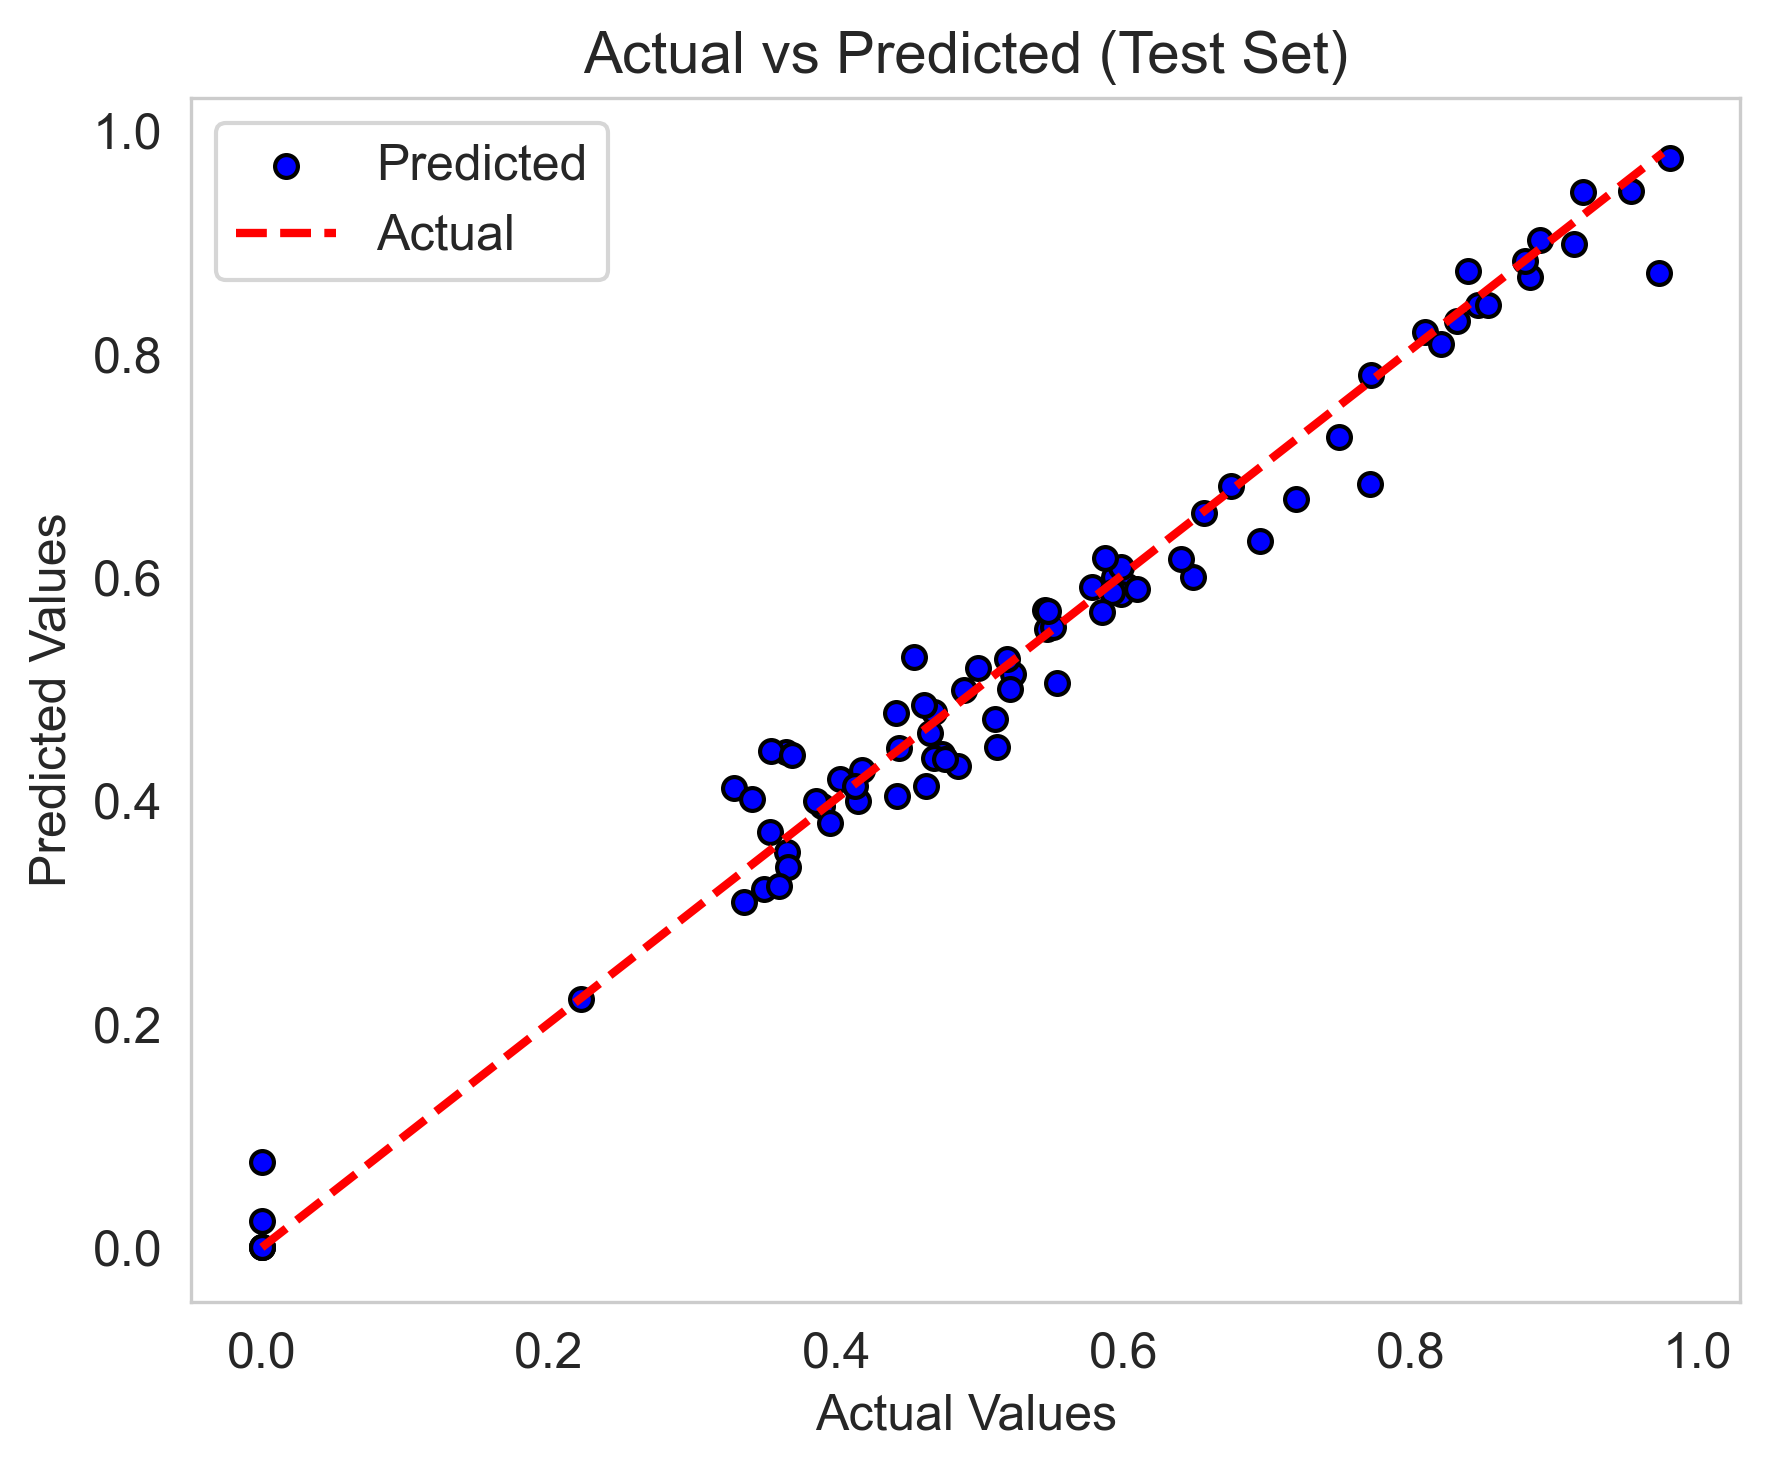

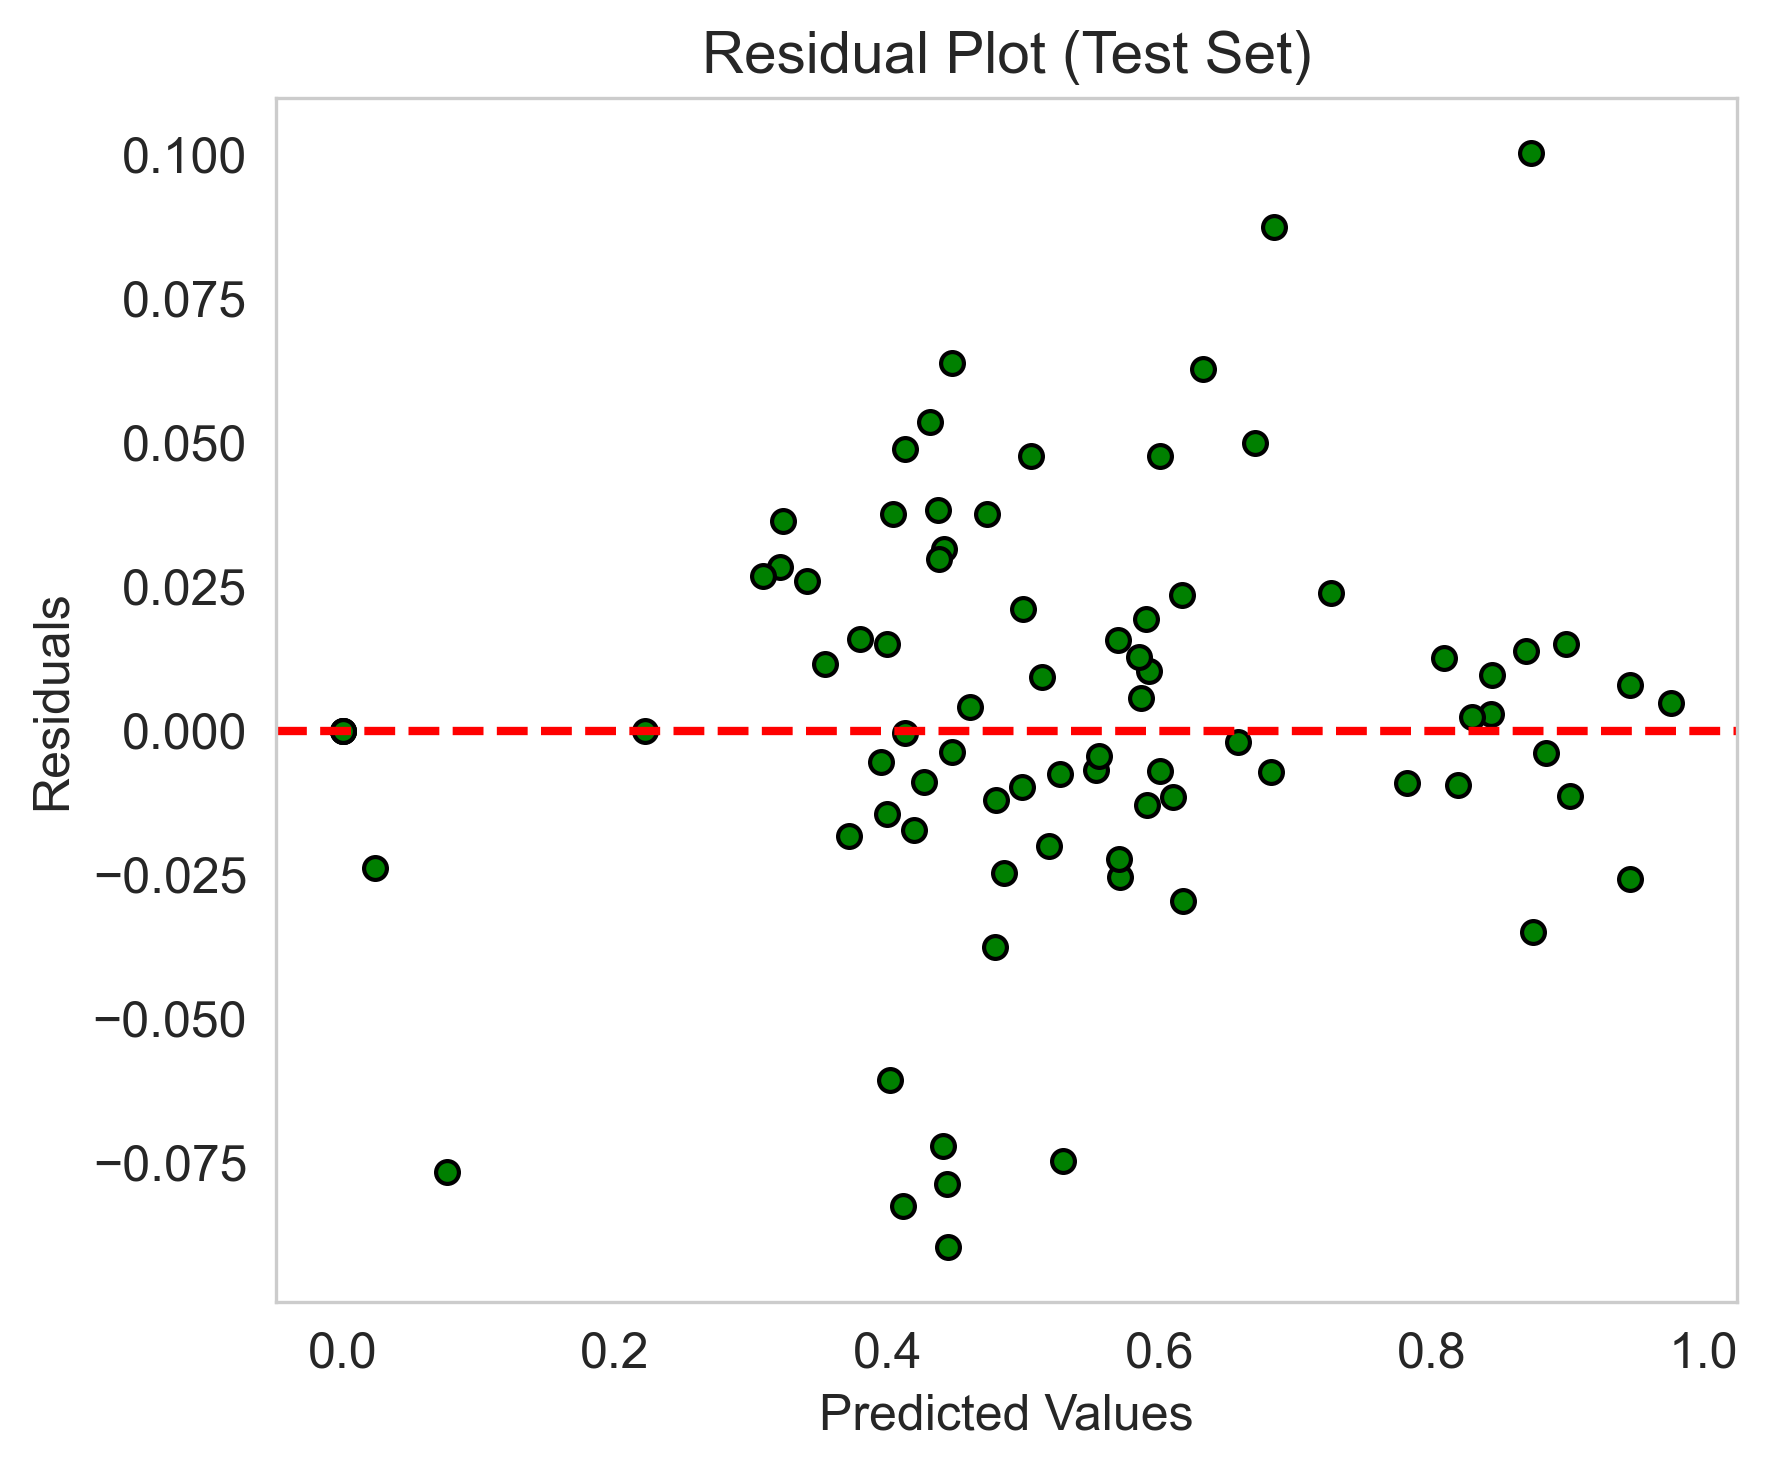

In [20]:
from matplotlib import rcParams

# Set font to Times New Roman globally
plt.rcParams["font.family"] = "Times New Roman"
sns.set_style("whitegrid")



def plot_actual_vs_pred(y_test, y_test_pred, title, save_path, dpi=300, figsize=(6, 5), font_size=12):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.scatter(y_test, y_test_pred, c='blue', label='Predicted', edgecolors='k', s=30)
    plt.plot([y_test.min(), y_test_pred.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Actual')
    plt.xlabel('Actual Values', fontsize=font_size)
    plt.ylabel('Predicted Values', fontsize=font_size)
    plt.title(title, fontsize=font_size + 2)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.legend(fontsize=font_size)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi)
    plt.show()
# Example usage
plot_actual_vs_pred(y_test, y_test_pred_rf, "Actual vs Predicted (Test Set)", "actual_vs_predicted.png")

def plot_residuals(y_test, y_test_pred, title, save_path, dpi=300, figsize=(6, 5), font_size=12):
    residuals = y_test - y_test_pred
    plt.figure(figsize=figsize, dpi=dpi)
    plt.scatter(y_test_pred, residuals, c='green', edgecolors='k', s=30)
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Predicted Values', fontsize=font_size)
    plt.ylabel('Residuals', fontsize=font_size)
    plt.title(title, fontsize=font_size + 2)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi)
    plt.show()

# Example usage
plot_residuals(y_test, y_test_pred_rf, "Residual Plot (Test Set)", "residual_plot.png")



In [66]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_root_error
from sklearn.metrics import mean_squared_error

# --- 1. Hyperparameter tuning for SVR ---
svr = SVR()
svr_param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto']
}
svr_search = RandomizedSearchCV(svr, svr_param_grid, n_iter=10, cv=5, scoring='r2', random_state=42)
svr_search.fit(X_train_scaled, y_train)
best_svr = svr_search.best_estimator_

# --- 2. Hyperparameter tuning for Random Forest ---
rf = RandomForestRegressor(random_state=42)
rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(rf, rf_param_grid, n_iter=10, cv=5, scoring='r2', random_state=42)
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_

# --- 3. Hyperparameter tuning for XGBoost ---
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(xgb, xgb_param_grid, n_iter=10, cv=5, scoring='r2', random_state=42)
xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_

# --- 4. Ensemble using Voting Regressor ---
ensemble = VotingRegressor(
    estimators=[('svr', best_svr), ('rf', best_rf), ('xgb', best_xgb)]
)
ensemble.fit(X_train_scaled, y_train)

# --- 5. Predictions ---
y_train_pred = ensemble.predict(X_train_scaled)
y_test_pred = ensemble.predict(X_test_scaled)

# --- 6. Metrics function ---

def regression_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_root_error(y_true, y_pred)  # updated for scikit-learn >=1.4
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# --- 7. Evaluate ---
r2_train, rmse_train, mae_train = regression_metrics(y_train, y_train_pred)
r2_test, rmse_test, mae_test = regression_metrics(y_test, y_test_pred)

print("Train Metrics: R²={:.3f}, RMSE={:.3f}, MAE={:.3f}".format(r2_train, rmse_train, mae_train))
print("Test Metrics:  R²={:.3f}, RMSE={:.3f}, MAE={:.3f}".format(r2_test, rmse_test, mae_test))


ImportError: cannot import name 'mean_squared_root_error' from 'sklearn.metrics' (c:\Users\SAIDUL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\__init__.py)

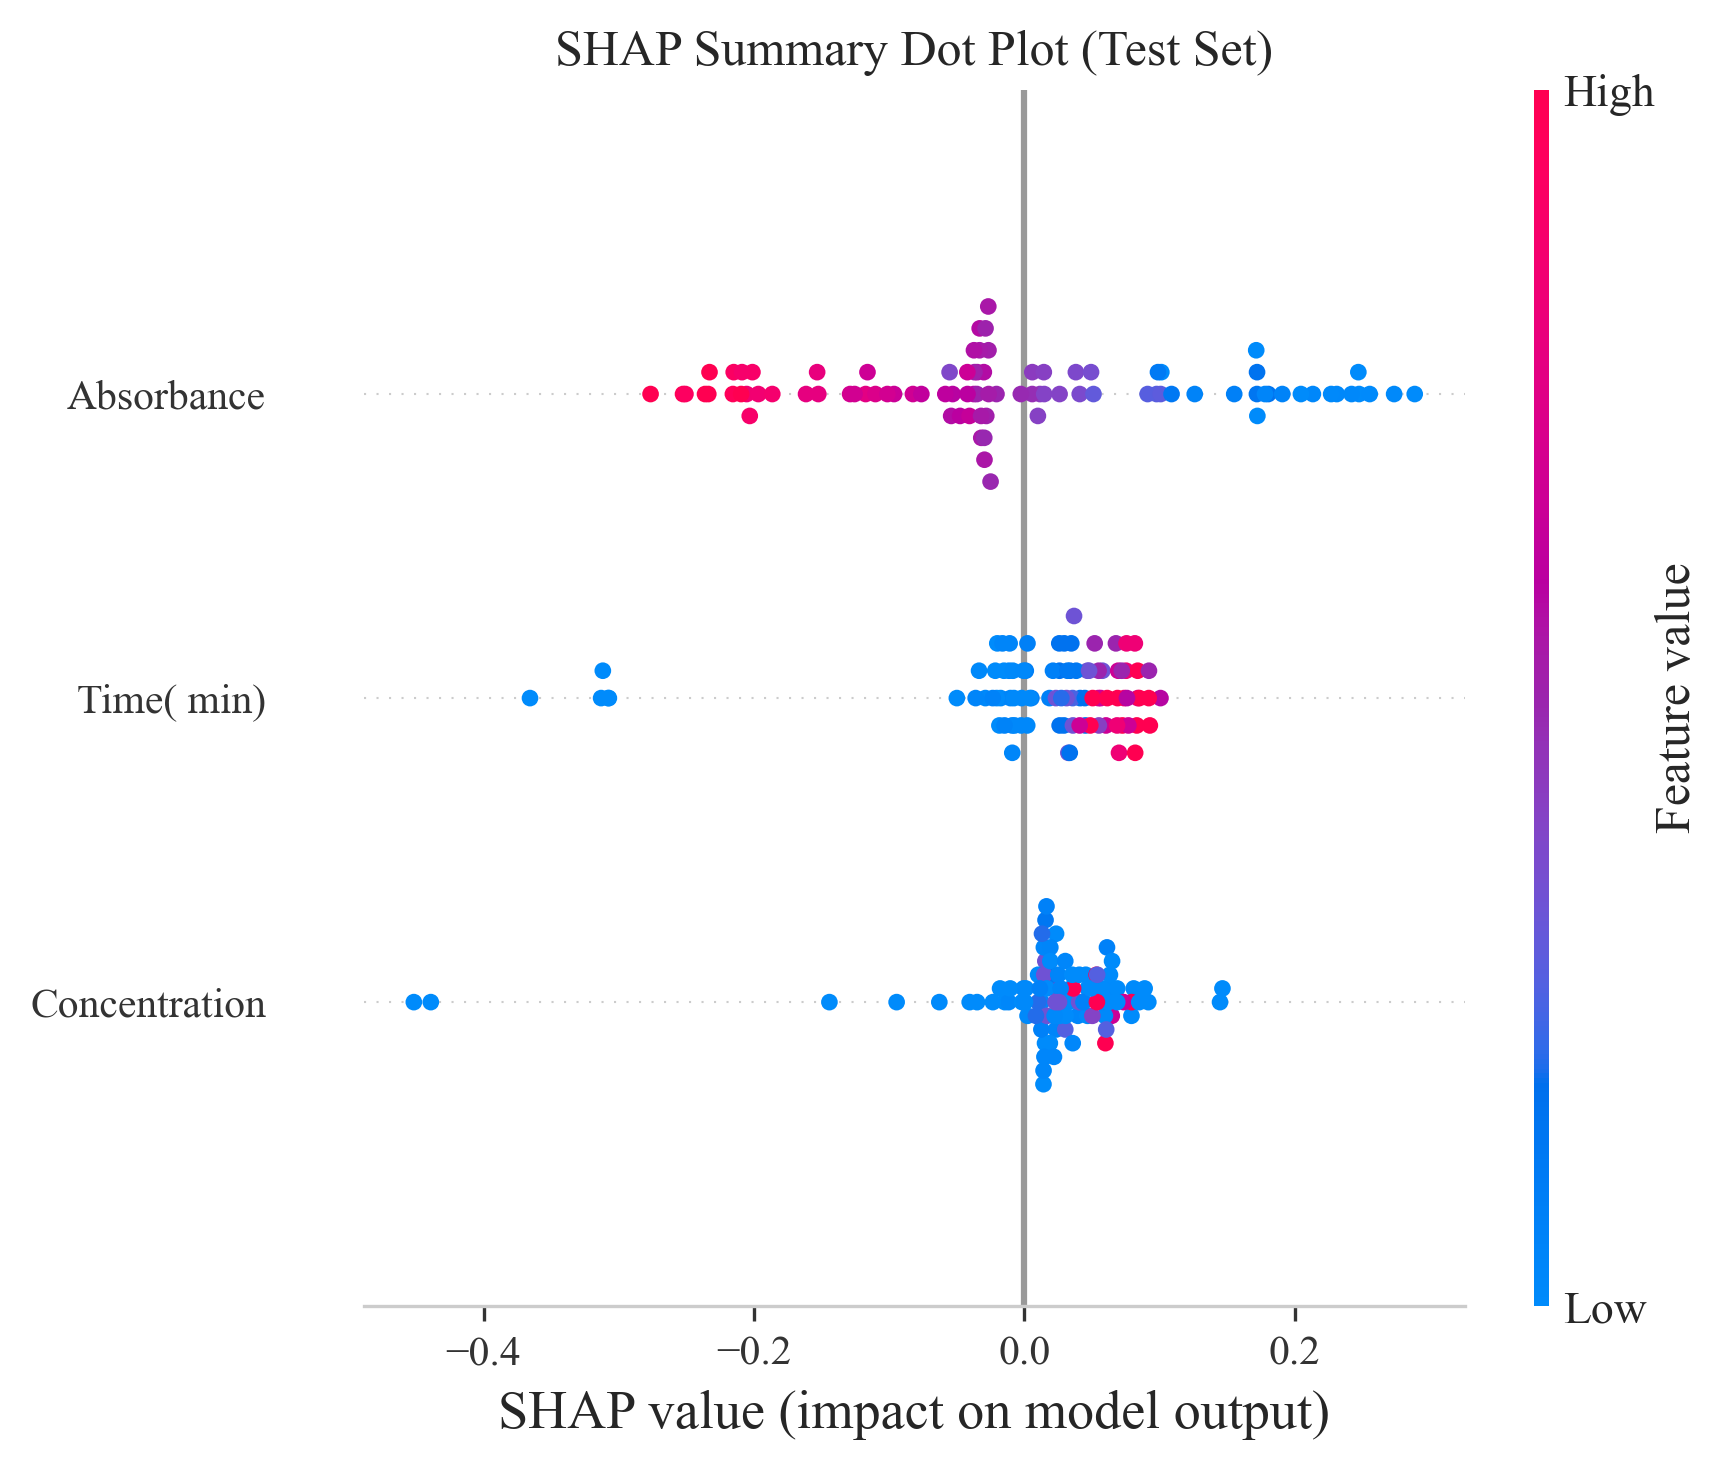

In [24]:
import shap
import matplotlib.pyplot as plt

def plot_shap_summary_dot(shap_values, X, title, save_path,
                          dpi=300, figsize=(6, 5), font_size=10):
    # Set font and figure quality
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["font.size"] = font_size
    plt.rcParams["axes.grid"] = False
    plt.rcParams["figure.dpi"] = dpi

    # Plot SHAP summary (dot plot)
    shap.summary_plot(shap_values, X, show=False, plot_size=figsize)

    # Apply styling after SHAP draws the plot
    fig = plt.gcf()
    ax = plt.gca()
    ax.set_title(title, fontsize=font_size + 2)
    ax.tick_params(axis='both', labelsize=font_size)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()


explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

plot_shap_summary_dot(
    shap_values,
    X_test,
    "SHAP Summary Dot Plot (Test Set)",
    "shap_summary_dot.png"
)
